In [2]:
#==================================================
# Imports
#==================================================
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray
import datetime
import calendar
import matplotlib
import os
#import h5py
import PseudoNetCDF as pnc
from scipy.ndimage import label
import scipy.interpolate as interp
import pickle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import scipy
from matplotlib.gridspec import GridSpec

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
start_date = datetime.datetime(2019,9,25)
date_str = '20190925'

# ===============================================
# Learjet
# ===============================================

In [4]:
path = '/pscratch/sd/m/mckenna/learjet/'+date_str+'/'
file_fcdp = path+'CAMP2Ex-FCDP_Learjet_'+date_str+'_R1.ict'
file_2ds10 = path+'CAMP2Ex-2DS10_Learjet_'+date_str+'_R0.ict'
file_hawk2ds10 = path+'CAMP2Ex-Hawk2DS10_Learjet_'+date_str+'_R0.ict'
file_hawk2ds50 = path+'CAMP2Ex-Hawk2DS50_Learjet_'+date_str+'_R0.ict'
file_hawkfcdp = path+'CAMP2Ex-HawkFCDP_Learjet_'+date_str+'_R1.ict'
file_bulk_props = path+'CAMP2Ex-CloudBulkProps_Learjet_'+date_str+'_R0.ICT'
file_hvps = path+'CAMP2Ex-HVPS_Learjet_'+date_str+'_R0.ict'
file_ffssp = path+'CAMP2Ex-FFSSP_Learjet_'+date_str+'_R0.ict'
file_state = path+'CAMP2Ex-Page0_Learjet_'+date_str+'_R0.ict'

# Process State & Bulk Props File to get cloud pass times

In [5]:
def process_state_bulk(state_file_name,bulk_file_name,start_date):
    """
    Processes the Bulk and State files from the Learjet flight.
    """
    
    
    #===========================================
    # State file
    #===========================================

    infile = pnc.pncopen(state_file_name, format = 'ffi1001')
    var_list = infile.variables
    keys = list(var_list.keys())
    #print(keys)
    # Make Datetime arrays
    secs_from_00z = var_list['Time_Start'].data
    nt = len(secs_from_00z)
    time = np.array([start_date + datetime.timedelta(seconds=secs_from_00z[dd]) for dd in range(nt)])
    
    # Pull out state properties
    pres_alt = var_list['Palt'].data # Pressure altitude (ft)
    temp = var_list['Temp'].data # temperature (C)
    dew = var_list['Dew'].data # dewpoint temperature (C)
    NevLWC = var_list['NevLWC'].data # Nevzorov LWC (g/m3)
    FSSPWC = var_list['FSSPWC'].data # FFSSP water content (g/m3)
    FCDPHWC = var_list['FCDPHWC'].data # Hawkeye-FCDP water content (g/m3)
    FCDPWC = var_list['FCDPWC'].data # FCDP water content (g/m3)
    NevTWC = var_list['NevTWC'].data # Nevzorov total water content (g/m3)
    VaV = var_list['VaV'].data # Vertical wind (updraft) (m/s)
    FSSPconc = var_list['FSSPConc'].data # FFSSP concentration (#/cc)
    FCDPHconc = var_list['FCDPHConc'].data # Hawkeye-FCDP concentration (#/cc)
    FCDPconc = var_list['FCDPConc'].data # FCDP concentration (#/cc)
    x2DSHsn10 = var_list['2DSHsn10'].data # SPEC 2D-S SN10 Concentration, H-channel (#/L)
    x2DSVsn10 = var_list['2DSVsn10'].data # SPEC 2D-S SN10 Concentration, V-channel (#/L)
    x2DSHNcar = var_list['2DSHNcar'].data # NCAR 2D-S Concentration, H-channel (#/L)
    x2DSVNcar = var_list['2DSVNcar'].data # NCAR 2D-S Concentration, V-channel (#/L)
    x2DS10Hawk = var_list['2DS10Hawk'].data # Hawkeye-2DS 10um channel concentration (#/L)
    x2DS50Hawk = var_list['2DS50Hawk'].data # Hawkeye-2DS 50um channel concentration (#/L)
    HVPS = var_list['HVPS'].data # HVPS concentration (#/L)
    CPC = var_list['CPC'].data # CPC concentration (#/cc)
    PCASP = var_list['PCASP'].data # PCASP concentration (#/cc)
    lat = var_list['Lat'].data
    lon = var_list['Long'].data
    tas = var_list['TAS'].data

    #cloud_id = np.where(NevTWC >= 0.1)[0]
    #cloud_mask = np.zeros(np.shape(NevTWC))
    #cloud_mask[cloud_id] = 1
    #cloud_passes,num_cloud_passes = label(cloud_mask)
    
    state_dict = {'pres_alt':pres_alt,\
                'temp':temp,\
                'dew':dew,\
                'NevLWC':NevLWC,\
                'FSSPWC':FSSPWC,\
                'FCDPHWC':FCDPHWC,\
                'FCDPWC':FCDPWC,\
                'NevTWC':NevTWC,\
                'VaV':VaV,\
                'FSSPconc':FSSPconc,\
                'FCDPHconc':FCDPHconc,\
                'FCDPconc':FCDPconc,\
                '2DSHsn10':x2DSHsn10,\
                '2DSVsn10':x2DSVsn10,\
                '2DSHNcar':x2DSHNcar,\
                '2DSVNcar':x2DSVNcar,\
                '2DS10Hawk':x2DS10Hawk,\
                '2DS50Hawk':x2DS50Hawk,\
                'HVPS':HVPS,\
                'CPC':CPC,\
                'PCASP':PCASP,\
                #'cloud_mask':cloud_mask,\
                'time':time,\
                'lat':lat,\
                'lon':lon,\
                'tas':tas,\
               }
    
    
    #===========================================
    # Bulk Props File
    #===========================================    
    infile = pnc.pncopen(bulk_file_name, format = 'ffi1001')
    var_list = infile.variables
    keys = list(var_list.keys())

    # Make Datetime arrays
    secs_from_00z = var_list['Time_Start'].data
    nt = len(secs_from_00z)
    time = np.array([start_date + datetime.timedelta(seconds=secs_from_00z[dd]) for dd in range(nt)])

    cp_type = var_list['CP_Type'].data # (#), none, Cloud pass type, 1 = "Cloud" High Concentration of small particles (WC>0.1g/m3 for scatter probes in 1-50um range), 2 = "Precip" High Concentration of HVPS Particles (N>100/s), 3 = "Scud" Cloud Flag >0
    conc_L = var_list['Concentration_L'] #  (#/L), CldMicro_NumSizeDist_InSitu_Imaging_DroptoPrecip_AMB, Cloud-averaged composite total particle concentration from interpolated concentration PSD(1um-10mm)
    iwc = var_list['IWC_gm3'].data # (g/m3), CldMicro_TWC_InSitu_None_Bulk_AMB,  Cloud-averaged composite Ice water content (all particles treated as Ice) from interpolated concentration PSD (1um-10mm) using Brown and Francis 1995 method
    lwc = var_list['LWC_gm3'].data #  (g/m3), CldMicro_TWC_InSitu_None_Bulk_AMB, Cloud-averaged composite Liquid water content (all particles treated as liquid Rho = 1kg/L) from interpolated concentration PSD (1um-10mm) assuming all spherical particles
    reff = var_list['Reff_um'].data # (um),   CldMicro_MeanSize_InSitu_Imaging_DroptoPrecip_None, Cloud-averaged composite Effective Radius from interpolated concentration PSD (1um-10mm)
    ze = var_list['Z_dBz'].data # (dBz),  none, Cloud-averaged composite (Estimated) Radar Reflectivity from interpolated concentration PSD (1um-10mm)    
    ze = var_list['Z_dBz'].data # (dBz),  none, Cloud-averaged composite (Estimated) Radar Reflectivity from interpolated concentration PSD (1um-10mm)    
    
    
    bulk_dict = {'time':time,\
                 'lat':lat,\
                 'lon':lon,\
                 'cp_type':cp_type,\
                 'conc_L':conc_L,\
                 'iwc':iwc,\
                 'lwc':lwc,\
                 'reff':reff,\
                 'ze':ze}
    
        
    return state_dict,bulk_dict

## Get state and bulk dicts

In [6]:
state_dict,bulk_dict = process_state_bulk(file_state,file_bulk_props,start_date)
print(state_dict.keys())
print(bulk_dict.keys())

dict_keys(['pres_alt', 'temp', 'dew', 'NevLWC', 'FSSPWC', 'FCDPHWC', 'FCDPWC', 'NevTWC', 'VaV', 'FSSPconc', 'FCDPHconc', 'FCDPconc', '2DSHsn10', '2DSVsn10', '2DSHNcar', '2DSVNcar', '2DS10Hawk', '2DS50Hawk', 'HVPS', 'CPC', 'PCASP', 'time', 'lat', 'lon', 'tas'])
dict_keys(['time', 'lat', 'lon', 'cp_type', 'conc_L', 'iwc', 'lwc', 'reff', 'ze'])


# Label Cloud Passes

In [7]:
nt = len(bulk_dict['time'])
cloud_mask_cp_type1 = np.zeros(nt)
cloud_mask_cp_type2 = np.zeros(nt)
cp_type = bulk_dict['cp_type']
cloud_id_type1 = np.where(cp_type == 1.)[0]

cloud_mask_cp_type1[cloud_id_type1] = 1

cp_type1,num_cp_type1 = label(cloud_mask_cp_type1)

In [8]:
cp_type1_time_dict = {}

#========================================
# Type 1 CP
#========================================
cp_id = 0
for ii in range(num_cp_type1):
    cloud_id = np.where(cp_type1 == ii+1)[0]
    
    start_id = cloud_id[0]
    end_id = cloud_id[-1]
    start_time = state_dict['time'][start_id]
    end_time = state_dict['time'][end_id]  
    
    cp_type1_time_dict[str(cp_id+1)] = {}
    cp_type1_time_dict[str(cp_id+1)]['start_time'] = start_time
    cp_type1_time_dict[str(cp_id+1)]['end_time'] = end_time
    cp_type1_time_dict[str(cp_id+1)]['start_id'] = start_id
    cp_type1_time_dict[str(cp_id+1)]['end_id'] = end_id
    
    cp_id+=1    

In [9]:
cp_type1_time_dict.keys()

dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23'])

# Process Probe PSDs

In [10]:
def process_ffssp(file_name,cp_type1_time_dict,cloud_pass_id,min_thresh):
    """
    Processes FFSSP instrument
    """
    cloud_pass_id = str(cloud_pass_id)
    infile = pnc.pncopen(file_name, format = 'ffi1001')
    var_list = infile.variables
    keys = list(var_list.keys())
    
    # Make Datetime arrays
    secs_from_00z = var_list['Time_Start'].data
    nt = len(secs_from_00z)
    time = np.array([start_date + datetime.timedelta(seconds=secs_from_00z[dd]) for dd in range(nt)])
    
    # Pull out bulk properties
    twc = var_list['twc'].data
    conc = var_list['conc'].data
    ext = var_list['ext'].data
    cnt = var_list['CNT'].data
    sv = var_list['sv'].data
        
    # Make a dictionary that holds the concentrations for each bin (#/L/um)
    cbin_dict = {}
    for key in keys:
        if 'cbin' in key:
            cbin_dict[key] = var_list[key].data
            
    # Make a dictionary that holds the concentrations for each bin (#)
    nbin_dict = {}
    for key in keys:
        if 'nbin' in key:
            nbin_dict[key] = var_list[key].data
            
    # Create dictionary of #/L
    nbin_L_dict = {}
    for key,val in nbin_dict.items():
        dumid = np.where(val > 0)
        tmp_val = val.copy()
        tmp_val[dumid] = val[dumid]/sv[dumid]
        nbin_L_dict[key] = tmp_val
            
    sizes = [0,1.5,3,4.5,6,8,10,12,14,16,18,21,24,27,30,33,36,39,42,46,50]
    mid_sizes = np.array([0.5*(sizes[dd] + sizes[dd+1]) for dd in range(len(sizes)-1)])
          
    start_time = cp_type1_time_dict[cloud_pass_id]['start_time']
    end_time = cp_type1_time_dict[cloud_pass_id]['end_time']
        
    time_ids = np.where( (time >= start_time) & (time <= end_time) )

    #================================
    # Composite dN
    #================================    
    comp_dN = np.zeros(len(sizes)-1)
    comp_dN_native = np.zeros(len(sizes)-1)
    nbin_keys = list(nbin_L_dict.keys())
    cbin_keys = list(cbin_dict.keys())
    last_nbin_key = nbin_keys[-1]
    last_cbin_key = cbin_keys[-1]
    
    ii=0
    for key,val in nbin_L_dict.items():

        if key == last_nbin_key:
            continue
        tmp_vals = val[time_ids]
        tmp_vals[tmp_vals < 0.] = np.nan
        tmp_vals_cbin = cbin_dict[cbin_keys[ii]][time_ids]
        tmp_vals_cbin[tmp_vals_cbin < 0.] = np.nan

        tmp_cnts = nbin_dict[key][time_ids]
        tmp_cnts[tmp_cnts < 0.] = np.nan
        tot_cnt = np.nansum(tmp_cnts)

        if tot_cnt > min_thresh:
            comp_dN[ii] = np.nanmean(tmp_vals)
            comp_dN_native[ii] = np.nanmean(tmp_vals_cbin)
        else:
            comp_dN[ii] = np.nan
            comp_dN_native[ii] = np.nan
        ii+=1
    comp_dN[comp_dN == 0.] = np.nan
    comp_dN_native[comp_dN_native == 0.] = np.nan
  
    return comp_dN,comp_dN_native,mid_sizes,sizes

In [11]:
def process_hawkeye_2ds50(file_name,cp_type1_time_dict,cloud_pass_id,min_thresh):
    """
    Processes Hawkeye 2DS50 instrument
    """
    cloud_pass_id = str(cloud_pass_id)
    infile = pnc.pncopen(file_name, format = 'ffi1001')
    var_list = infile.variables
    keys = list(var_list.keys())
    
    # Make Datetime arrays
    secs_from_00z = var_list['Time_Start'].data
    nt = len(secs_from_00z)
    time = np.array([start_date + datetime.timedelta(seconds=secs_from_00z[dd]) for dd in range(nt)])
    
    # Pull out bulk properties
    twc = var_list['twc'].data
    conc = var_list['conc'].data
    ext = var_list['ext'].data
    sv = var_list['sv'].data
        
    # Make a dictionary that holds the concentrations for each bin (#/L/um)
    cbin_dict = {}
    for key in keys:
        if 'cbin' in key:
            cbin_dict[key] = var_list[key].data
            
    # Make a dictionary that holds the concentrations for each bin (#)
    nbin_dict = {}
    for key in keys:
        if 'nbin' in key:
            nbin_dict[key] = var_list[key].data                
            
    # Create dictionary of #/L
    nbin_L_dict = {}
    for key,val in nbin_dict.items():
        dumid = np.where(val > 0)
        tmp_val = val.copy()
        tmp_val[dumid] = val[dumid]/sv[dumid]
        nbin_L_dict[key] = tmp_val
            
    sizes_1 = np.arange(25,1075,50)
    sizes_2 = np.arange(1125,2625,100)
    sizes_3 = np.array([2775,3025,3225,3525,3775,4025,4275,4525,4775,5025,5525,6025,6525,7025,7525,8025,8525,9025,9525,10025,11025,12025,13025,14025,15025])
    sizes = np.concatenate((sizes_1,sizes_2,sizes_3))
        
    mid_sizes = np.array([0.5*(sizes[dd] + sizes[dd+1]) for dd in range(len(sizes)-1)])           
          
    start_time = cp_type1_time_dict[cloud_pass_id]['start_time']
    end_time = cp_type1_time_dict[cloud_pass_id]['end_time']
        
    time_ids = np.where( (time >= start_time) & (time <= end_time) )
        
    #================================
    # Composite dN
    #================================    
    comp_dN = np.zeros(len(sizes)-1)
    comp_dN_native = np.zeros(len(sizes)-1)
    nbin_keys = list(nbin_L_dict.keys())
    cbin_keys = list(cbin_dict.keys())
    last_nbin_key = nbin_keys[-1]
    last_cbin_key = cbin_keys[-1]
    
    ii=0
    for key,val in nbin_L_dict.items():

        if key == last_nbin_key:
            continue
        tmp_vals = val[time_ids]
        tmp_vals[tmp_vals < 0.] = np.nan
        tmp_vals_cbin = cbin_dict[cbin_keys[ii]][time_ids]
        tmp_vals_cbin[tmp_vals_cbin < 0.] = np.nan

        tmp_cnts = nbin_dict[key][time_ids]
        tmp_cnts[tmp_cnts < 0.] = np.nan
        tot_cnt = np.nansum(tmp_cnts)

        if tot_cnt > min_thresh:
            comp_dN[ii] = np.nanmean(tmp_vals)
            comp_dN_native[ii] = np.nanmean(tmp_vals_cbin)
        else:
            comp_dN[ii] = np.nan
            comp_dN_native[ii] = np.nan
        ii+=1
    comp_dN[comp_dN == 0.] = np.nan
    comp_dN_native[comp_dN_native == 0.] = np.nan
  
    return comp_dN,comp_dN_native,mid_sizes,sizes

In [12]:
def process_fcdp(file_name,cp_type1_time_dict,cloud_pass_id,min_thresh):
    """
    Processes FCDP instrument
    """
    cloud_pass_id = str(cloud_pass_id)
    infile = pnc.pncopen(file_name, format = 'ffi1001')
    var_list = infile.variables
    keys = list(var_list.keys())
    
    # Make Datetime arrays
    secs_from_00z = var_list['Time_Start'].data
    nt = len(secs_from_00z)
    time = np.array([start_date + datetime.timedelta(seconds=secs_from_00z[dd]) for dd in range(nt)])
    
    # Pull out bulk properties
    twc = var_list['twc'].data
    conc = var_list['conc'].data
    ext = var_list['ext'].data
    sv = var_list['sv'].data
        
    # Make a dictionary that holds the concentrations for each bin (#/L/um)
    cbin_dict = {}
    for key in keys:
        if 'cbin' in key:
            cbin_dict[key] = var_list[key].data
            
    # Make a dictionary that holds the concentrations for each bin (#/L)
    nbin_dict = {}
    for key in keys:
        if 'nbin' in key:
            nbin_dict[key] = var_list[key].data                

    # Create dictionary of #/L
    nbin_L_dict = {}
    for key,val in nbin_dict.items():
        dumid = np.where(val > 0)
        tmp_val = val.copy()
        tmp_val[dumid] = val[dumid]/sv[dumid]
        nbin_L_dict[key] = tmp_val
            
    sizes = np.array([0,1.5,3,4.5,6,8,10,12,14,16,18,21,24,27,30,33,36,39,42,46,50])
        
    mid_sizes = np.array([0.5*(sizes[dd] + sizes[dd+1]) for dd in range(len(sizes)-1)])           
          
    start_time = cp_type1_time_dict[cloud_pass_id]['start_time']
    end_time = cp_type1_time_dict[cloud_pass_id]['end_time']
        
    time_ids = np.where( (time >= start_time) & (time <= end_time) )
        
    #================================
    # Composite dN
    #================================    
    comp_dN = np.zeros(len(sizes)-1)
    comp_dN_native = np.zeros(len(sizes)-1)
    nbin_keys = list(nbin_L_dict.keys())
    cbin_keys = list(cbin_dict.keys())
    last_nbin_key = nbin_keys[-1]
    last_cbin_key = cbin_keys[-1]
    
    ii=0
    for key,val in nbin_L_dict.items():

        if key == last_nbin_key:
            continue
        tmp_vals = val[time_ids]
        tmp_vals[tmp_vals < 0.] = np.nan
        tmp_vals_cbin = cbin_dict[cbin_keys[ii]][time_ids]
        tmp_vals_cbin[tmp_vals_cbin < 0.] = np.nan

        tmp_cnts = nbin_dict[key][time_ids]
        tmp_cnts[tmp_cnts < 0.] = np.nan
        tot_cnt = np.nansum(tmp_cnts)

        if tot_cnt > min_thresh:
            comp_dN[ii] = np.nanmean(tmp_vals)
            comp_dN_native[ii] = np.nanmean(tmp_vals_cbin)
        else:
            comp_dN[ii] = np.nan
            comp_dN_native[ii] = np.nan
        ii+=1
    comp_dN[comp_dN == 0.] = np.nan
    comp_dN_native[comp_dN_native == 0.] = np.nan
  
    return comp_dN,comp_dN_native,mid_sizes,sizes    

In [13]:
def process_hvps(file_name,cp_type1_time_dict,cloud_pass_id,min_thresh):
    """
    Processes HVPS instrument
    """
    cloud_pass_id = str(cloud_pass_id)
    infile = pnc.pncopen(file_name, format = 'ffi1001')
    var_list = infile.variables
    keys = list(var_list.keys())
    
    # Make Datetime arrays
    secs_from_00z = var_list['Time_Start'].data
    nt = len(secs_from_00z)
    time = np.array([start_date + datetime.timedelta(seconds=secs_from_00z[dd]) for dd in range(nt)])
    
    # Pull out bulk properties
    twc = var_list['twc'].data
    conc = var_list['conc'].data
    ext = var_list['ext'].data
    #cnt = var_list['CNT'].data
    sv = var_list['sv'].data
        
    # Make a dictionary that holds the concentrations for each bin (#/L/um)
    cbin_dict = {}
    for key in keys:
        if 'cbin' in key:
            cbin_dict[key] = var_list[key].data
            
    # Make a dictionary that holds the concentrations for each bin (#)
    nbin_dict = {}
    for key in keys:
        if 'nbin' in key:
            nbin_dict[key] = var_list[key].data                

    # Create dictionary of #/L
    nbin_L_dict = {}
    for key,val in nbin_dict.items():
        dumid = np.where(val > 0)
        tmp_val = val.copy()
        tmp_val[dumid] = val[dumid]/sv[dumid]
        nbin_L_dict[key] = tmp_val
            
    sizes = np.array([75,225,375,525,675,825,975,1125,1275,1425,1575,1725,1875,2025,2175,2325,2475,2625,2775,2925,3075,3375,3675,3975,4275,4575,4875,5175,5475,5775,6075,6375,6675,6975,7275,7575,8325,9075,9825,10575,11325,12074,12824,13574,\
                     14325,15075,16575,18074,19574,21075,22574,24074,25574,27074,28574,30075,33075,36075,39075,42075,45075])

    mid_sizes = np.array([0.5*(sizes[dd] + sizes[dd+1]) for dd in range(len(sizes)-1)])           
          
    start_time = cp_type1_time_dict[cloud_pass_id]['start_time']
    end_time = cp_type1_time_dict[cloud_pass_id]['end_time']
        
    time_ids = np.where( (time >= start_time) & (time <= end_time) )
        

    #================================
    # Composite dN
    #================================    
    comp_dN = np.zeros(len(sizes)-1)
    comp_dN_native = np.zeros(len(sizes)-1)
    nbin_keys = list(nbin_L_dict.keys())
    cbin_keys = list(cbin_dict.keys())
    last_nbin_key = nbin_keys[-1]
    last_cbin_key = cbin_keys[-1]
    
    ii=0
    for key,val in nbin_L_dict.items():

        if key == last_nbin_key:
            continue
        tmp_vals = val[time_ids]
        tmp_vals[tmp_vals < 0.] = np.nan
        tmp_vals_cbin = cbin_dict[cbin_keys[ii]][time_ids]
        tmp_vals_cbin[tmp_vals_cbin < 0.] = np.nan

        tmp_cnts = nbin_dict[key][time_ids]
        tmp_cnts[tmp_cnts < 0.] = np.nan
        tot_cnt = np.nansum(tmp_cnts)

        if tot_cnt > min_thresh:
            comp_dN[ii] = np.nanmean(tmp_vals)
            comp_dN_native[ii] = np.nanmean(tmp_vals_cbin)
        else:
            comp_dN[ii] = np.nan
            comp_dN_native[ii] = np.nan
        ii+=1
    comp_dN[comp_dN == 0.] = np.nan
    comp_dN_native[comp_dN_native == 0.] = np.nan
  
    return comp_dN,comp_dN_native,mid_sizes,sizes      

In [14]:
def process_2ds10(file_name,cp_type1_time_dict,cloud_pass_id,min_thresh):
    """
    Processes 2DS10 instrument
    """
    cloud_pass_id = str(cloud_pass_id)
    infile = pnc.pncopen(file_name, format = 'ffi1001')
    var_list = infile.variables
    keys = list(var_list.keys())
    
    # Make Datetime arrays
    secs_from_00z = var_list['Time_Start'].data
    nt = len(secs_from_00z)
    time = np.array([start_date + datetime.timedelta(seconds=secs_from_00z[dd]) for dd in range(nt)])
    
    # Pull out bulk properties
    twc = var_list['twc'].data
    conc = var_list['conc'].data
    ext = var_list['ext'].data
    #cnt = var_list['CNT'].data
    sv = var_list['sv'].data

    sizes_1 = np.arange(5,215,10)
    sizes_2 = np.arange(225,525,20)
    sizes_3 = np.arange(555,1055,50)
    sizes_4 = np.arange(1105,2105,100)
    sizes_5 = np.arange(2205,3205,200)
    sizes = np.concatenate((sizes_1,sizes_2,sizes_3,sizes_4,sizes_5))
    
    # Make a dictionary that holds the concentrations for each bin (#/L/um)
    # Number/L/um
    cbin_dict = {}
    for key in keys:
        if 'cbin' in key:
            cbin_dict[key] = var_list[key].data
            
    # Make a dictionary that holds the counts for each bin (#)
    # Number only
    nbin_dict = {}
    for key in keys:
        if 'nbin' in key:
            nbin_dict[key] = var_list[key].data                

            
    # Create dictionary of #/L
    # Number/liter
    #counter=0
    nbin_L_dict = {}
    for key,val in nbin_dict.items():
       # dD = sizes[counter+1]-sizes[counter]
        dumid = np.where(val > 0)
        tmp_val = val.copy()
        tmp_val[dumid] = val[dumid]/sv[dumid]#/dD
        nbin_L_dict[key] = tmp_val
        #counter+=1



    
    mid_sizes = np.array([0.5*(sizes[dd] + sizes[dd+1]) for dd in range(len(sizes)-1)])           
          
    start_time = cp_type1_time_dict[cloud_pass_id]['start_time']
    end_time = cp_type1_time_dict[cloud_pass_id]['end_time']
        
    time_ids = np.where( (time >= start_time) & (time <= end_time) )
    
    #================================
    # Composite dN
    #================================    
    comp_dN = np.zeros(len(sizes)-1)
    comp_dN_native = np.zeros(len(sizes)-1)
    nbin_keys = list(nbin_L_dict.keys())
    cbin_keys = list(cbin_dict.keys())
    last_nbin_key = nbin_keys[-1]
    last_cbin_key = cbin_keys[-1]
    
    ii=0
    for key,val in nbin_L_dict.items():
        #print(key,val)
        if key == last_nbin_key:
            continue
        tmp_vals = val[time_ids]
        tmp_vals[tmp_vals < 0.] = np.nan
        tmp_vals_cbin = cbin_dict[cbin_keys[ii]][time_ids]
        tmp_vals_cbin[tmp_vals_cbin < 0.] = np.nan

        tmp_cnts = nbin_dict[key][time_ids]
        tmp_cnts[tmp_cnts < 0.] = np.nan
        tot_cnt = np.nansum(tmp_cnts)

        if tot_cnt > min_thresh:
            comp_dN[ii] = np.nanmean(tmp_vals)
            comp_dN_native[ii] = np.nanmean(tmp_vals_cbin)
        else:
            comp_dN[ii] = np.nan
            comp_dN_native[ii] = np.nan
        ii+=1
    comp_dN[comp_dN == 0.] = np.nan
    comp_dN_native[comp_dN_native == 0.] = np.nan
  
    return comp_dN,comp_dN_native,mid_sizes,sizes

# Choose specific cloud passes based on prior analysis

In [15]:
if False:
    target_1_id = '20' # 06:06:13 - 06:06:16 (3 seconds); -7.425 deg C; max w: 4.4 m/s; mean w: 1.325 m/s
    target_2_id = '21' # 06:06:35 - 06:06:38 (3 seconds); -7.275 deg C; max w: 3.6 m/s; mean w: 1.85 m/s
    target_3_id = '22' # 06:12:12 - 06:12:35 (23 seconds); -14.57 deg C;  max w: 20.9 m/s; mean w: 9.55 m/s
    target_4_id = '23' # 06:13:10 - 06:13:18 (8 seconds); -14.76 deg C; max w: 16 m/s; mean w: 3.13 m/s
    
    
    target_id_dict = {'1':target_1_id,\
                      '2':target_2_id,\
                      '3':target_3_id,\
                      '4':target_4_id,\
                     }

In [16]:

counter = 1
target_id_dict = {}
for key in cp_type1_time_dict.keys():
    time = state_dict['time']
    start_time = cp_type1_time_dict[key]['start_time']
    end_time = cp_type1_time_dict[key]['end_time']
    start_id = cp_type1_time_dict[key]['start_id']
    end_id = cp_type1_time_dict[key]['end_id']+1    
    temp_out = state_dict['temp'][start_id:end_id]
    w_out = state_dict['VaV'][start_id:end_id]

    if np.mean(temp_out) < 1.5:
        print('CP #',key)
        print('Time window:',start_time,end_time)
        print('mean_temp:',np.mean(temp_out))
        print('min. temp:',np.min(temp_out))
        print('max. temp:',np.max(temp_out))
        print('mean w:',np.mean(w_out))
        print('min. w:',np.min(w_out))
        print('max. w:',np.max(w_out))
        target_id_dict[str(counter)] = key
        counter+=1
    


CP # 19
Time window: 2019-09-25 06:02:07 2019-09-25 06:02:17
mean_temp: 1.0363636363636366
min. temp: 0.3
max. temp: 2.0
mean w: 4.154545454545454
min. w: -2.6
max. w: 9.2
CP # 20
Time window: 2019-09-25 06:06:13 2019-09-25 06:06:16
mean_temp: -7.425
min. temp: -7.7
max. temp: -7.2
mean w: 1.3250000000000002
min. w: -2.1
max. w: 4.4
CP # 21
Time window: 2019-09-25 06:06:35 2019-09-25 06:06:38
mean_temp: -7.275
min. temp: -7.5
max. temp: -6.9
mean w: 1.8499999999999999
min. w: -0.2
max. w: 3.6
CP # 22
Time window: 2019-09-25 06:12:12 2019-09-25 06:12:35
mean_temp: -14.570833333333335
min. temp: -16.4
max. temp: -12.8
mean w: 9.549999999999999
min. w: -5.4
max. w: 20.9
CP # 23
Time window: 2019-09-25 06:13:10 2019-09-25 06:13:18
mean_temp: -14.755555555555556
min. temp: -15.9
max. temp: -12.9
mean w: 3.1333333333333337
min. w: -4.0
max. w: 16.0


In [17]:
state_dict.keys()

dict_keys(['pres_alt', 'temp', 'dew', 'NevLWC', 'FSSPWC', 'FCDPHWC', 'FCDPWC', 'NevTWC', 'VaV', 'FSSPconc', 'FCDPHconc', 'FCDPconc', '2DSHsn10', '2DSVsn10', '2DSHNcar', '2DSVNcar', '2DS10Hawk', '2DS50Hawk', 'HVPS', 'CPC', 'PCASP', 'time', 'lat', 'lon', 'tas'])

In [25]:
top_dict = {}
counter = 1
for key,val in target_id_dict.items():
    print('Cloud Pass '+str(counter)+':')
    min_thresh = 0
    cloud_pass_id = val
    
    top_dict[cloud_pass_id] = {}
    
    time = state_dict['time']
    start_time = cp_type1_time_dict[cloud_pass_id]['start_time']
    end_time = cp_type1_time_dict[cloud_pass_id]['end_time']
    start_id = cp_type1_time_dict[cloud_pass_id]['start_id']
    end_id = cp_type1_time_dict[cloud_pass_id]['end_id']+1    
    print('Time window:',start_time,end_time)
    

    ffssp_comp_dN,ffssp_comp_dN_native,ffssp_mid_sizes,ffssp_sizes = process_ffssp(file_ffssp,cp_type1_time_dict,cloud_pass_id,min_thresh)
    fcdp_comp_dN,fcdp_comp_dN_native,fcdp_mid_sizes,fcdp_sizes = process_fcdp(file_fcdp,cp_type1_time_dict,cloud_pass_id,min_thresh)
    hawkeye_fcdp_comp_dN,hawkeye_fcdp_comp_dN_native,fcdp_mid_sizes,fcdp_sizes = process_fcdp(file_hawkfcdp,cp_type1_time_dict,cloud_pass_id,min_thresh)
    x2ds10_comp_dN,x2ds10_comp_dN_native,x2ds10_mid_sizes,x2ds10_sizes = process_2ds10(file_2ds10,cp_type1_time_dict,cloud_pass_id,min_thresh)
    hawkeye_2ds10_comp_dN,hawkeye_2ds10_comp_dN_native,x2ds10_mid_sizes,x2ds10_sizes = process_2ds10(file_hawk2ds10,cp_type1_time_dict,cloud_pass_id,min_thresh)
    hawkeye_2ds50_comp_dN,hawkeye_2ds50_comp_dN_native,hawkeye_2ds50_mid_sizes,hawkeye_2ds50_sizes = process_hawkeye_2ds50(file_hawk2ds50,cp_type1_time_dict,cloud_pass_id,min_thresh)
    hvps_comp_dN,hvps_comp_dN_native,hvps_mid_sizes,hvps_sizes = process_hvps(file_hvps,cp_type1_time_dict,cloud_pass_id,min_thresh)

    
    # Put all DSDs into dictionary
    dsd_dict = {'ffssp':{},\
                'fcdp':{},\
                'hawkfcdp':{},\
                '2ds10':{},\
                'hawk2ds10':{},\
                'hawk2ds50':{},\
                'hvps':{},\
               }
    dsd_dict['ffssp']['dsd'] = ffssp_comp_dN
    dsd_dict['ffssp']['dsd_native'] = ffssp_comp_dN_native
    dsd_dict['ffssp']['sizes'] = ffssp_sizes
    dsd_dict['ffssp']['mid_sizes'] = ffssp_mid_sizes
    dsd_dict['fcdp']['dsd'] = fcdp_comp_dN
    dsd_dict['fcdp']['dsd_native'] = fcdp_comp_dN_native
    dsd_dict['fcdp']['sizes'] = fcdp_sizes  
    dsd_dict['fcdp']['mid_sizes'] = fcdp_mid_sizes  
    dsd_dict['hawkfcdp']['dsd'] = hawkeye_fcdp_comp_dN
    dsd_dict['hawkfcdp']['dsd_native'] = hawkeye_fcdp_comp_dN_native
    dsd_dict['hawkfcdp']['sizes'] = fcdp_sizes  
    dsd_dict['hawkfcdp']['mid_sizes'] = fcdp_mid_sizes  
    dsd_dict['2ds10']['dsd'] = x2ds10_comp_dN
    dsd_dict['2ds10']['dsd_native'] = x2ds10_comp_dN_native
    dsd_dict['2ds10']['sizes'] = x2ds10_sizes 
    dsd_dict['2ds10']['mid_sizes'] = x2ds10_mid_sizes 
    dsd_dict['hawk2ds10']['dsd'] = hawkeye_2ds10_comp_dN
    dsd_dict['hawk2ds10']['dsd_native'] = hawkeye_2ds10_comp_dN_native
    dsd_dict['hawk2ds10']['sizes'] = x2ds10_sizes  
    dsd_dict['hawk2ds10']['mid_sizes'] = x2ds10_mid_sizes  
    dsd_dict['hawk2ds50']['dsd'] = hawkeye_2ds50_comp_dN
    dsd_dict['hawk2ds50']['dsd_native'] = hawkeye_2ds50_comp_dN_native
    dsd_dict['hawk2ds50']['sizes'] = hawkeye_2ds50_sizes 
    dsd_dict['hawk2ds50']['mid_sizes'] = hawkeye_2ds50_mid_sizes 
    dsd_dict['hvps']['dsd'] = hvps_comp_dN
    dsd_dict['hvps']['dsd_native'] = hvps_comp_dN_native
    dsd_dict['hvps']['sizes'] = hvps_sizes  
    dsd_dict['hvps']['mid_sizes'] = hvps_mid_sizes  
    
    #========================
    # Grab some bulk/state properties as well
    #========================
    
    mean_conc = np.mean(bulk_dict['conc_L'][start_id:end_id])*1.e-3
    mean_lwc = np.mean(bulk_dict['lwc'][start_id:end_id])  
    mean_iwc = np.mean(bulk_dict['iwc'][start_id:end_id])
    mean_dbz = np.mean(bulk_dict['ze'][start_id:end_id])
    mean_reff = np.mean(bulk_dict['reff'][start_id:end_id])
    
    w_out = state_dict['VaV'][start_id:end_id]
    nev_lwc_out = state_dict['NevLWC'][start_id:end_id]
    nev_twc_out = state_dict['NevTWC'][start_id:end_id]
    fcdp_wc_out = state_dict['FCDPWC'][start_id:end_id]
    fssp_wc_out = state_dict['FSSPWC'][start_id:end_id]
    fcdp_hawk_wc_out = state_dict['FCDPHWC'][start_id:end_id]
    
    fcdp_conc_out = state_dict['FCDPconc'][start_id:end_id]
    fssp_conc_out = state_dict['FSSPconc'][start_id:end_id]
    fcdp_hawk_conc_out = state_dict['FCDPHconc'][start_id:end_id]
    hvps_conc_out = state_dict['HVPS'][start_id:end_id]
    x2ds50_hawk_conc_out = state_dict['2DS50Hawk'][start_id:end_id]
    x2dshsn10_conc_out = state_dict['2DSHsn10'][start_id:end_id]
    x2dsvsn10_conc_out = state_dict['2DSVsn10'][start_id:end_id]
    x2ds10_hawk_conc_out = state_dict['2DS10Hawk'][start_id:end_id]
    temp_out = state_dict['temp'][start_id:end_id]
    dew_out = state_dict['dew'][start_id:end_id]  
    
    # Calculate RH
    beta = 17.625
    lamb = 243.04
    num = np.exp( (beta*state_dict['dew']) / (lamb + state_dict['dew']) )
    den = np.exp( (beta*state_dict['temp']) / (lamb + state_dict['temp']) )
    rh = 100. * (num/den)
    
    rh_out = rh[start_id:end_id]
    alt_out = state_dict['pres_alt'][start_id:end_id]*0.3048
    print('mean_temp:',np.mean(temp_out))
    print('min. temp:',np.min(temp_out))
    print('max. temp:',np.max(temp_out))
    print('mean w:',np.mean(w_out))
    print('min. w:',np.min(w_out))
    print('max. w:',np.max(w_out))
    print('')
    cp_dict = {'conc_cc':bulk_dict['conc_L'][start_id-2:end_id+2].data*1.e-3,\
           'lwc':bulk_dict['lwc'][start_id-2:end_id+2],\
           'NevLWC':state_dict['NevLWC'][start_id-2:end_id+2],\
           'NevTWC':state_dict['NevTWC'][start_id-2:end_id+2],\
           'FFSSP_conc':fssp_conc_out,\
           'FCDP_conc':fcdp_conc_out,\
           'FCDP_hawk_conc':fcdp_hawk_conc_out,\
           'HVPS_conc':hvps_conc_out,\
           '2DS50_hawk_conc':x2ds50_hawk_conc_out,\
           '2DS10_hawk_conc':x2ds10_hawk_conc_out,\
           '2DSH10_conc':x2dshsn10_conc_out,\
           '2DSV10_conc':x2dsvsn10_conc_out,\
           'iwc':bulk_dict['iwc'][start_id-2:end_id+2],\
           'dbz':bulk_dict['ze'][start_id-2:end_id+2],\
           'reff':bulk_dict['reff'][start_id-2:end_id+2],\
           'lat':bulk_dict['lat'][start_id-2:end_id+2],\
           'lon':bulk_dict['lon'][start_id-2:end_id+2],\
           'temp':temp_out,\
           'mean_temp':np.mean(temp_out),\
           'max_temp':np.max(temp_out),\
           'min_temp':np.min(temp_out),\
           'dew':dew_out,\
           'rh':rh_out,\
           'alt':alt_out,\
           'w':state_dict['VaV'][start_id-2:end_id+2],\
           'mean_w':np.mean(w_out),\
           'max_w':np.max(w_out),\
           'min_w':np.min(w_out),\
           'mean_NevLWC':np.mean(state_dict['NevLWC'][start_id:end_id]),\
           'max_NevLWC':np.max(state_dict['NevLWC'][start_id:end_id]),\
           'min_NevLWC':np.min(state_dict['NevLWC'][start_id:end_id]),\
           'mean_NevTWC':np.mean(state_dict['NevTWC'][start_id:end_id]),\
           'max_NevTWC':np.max(state_dict['NevTWC'][start_id:end_id]),\
           'min_NevTWC':np.min(state_dict['NevTWC'][start_id:end_id]),\
           'time':time[start_id-2:end_id+2],\
           'tas':state_dict['tas'][start_id:end_id],\
           'seg_length':np.sum(state_dict['tas'][start_id:end_id]),\
           'seg_time_length':len(time[start_id:end_id]),\
           'seg_start_time':time[start_id],\
           'seg_end_time':time[end_id],\
          }
    
    top_dict[cloud_pass_id]['bulk_dict'] = cp_dict
    top_dict[cloud_pass_id]['dsd_dict'] = dsd_dict

    counter+=1

Cloud Pass 1:
Time window: 2019-09-25 06:02:07 2019-09-25 06:02:17
mean_temp: 1.0363636363636366
min. temp: 0.3
max. temp: 2.0
mean w: 4.154545454545454
min. w: -2.6
max. w: 9.2

Cloud Pass 2:
Time window: 2019-09-25 06:06:13 2019-09-25 06:06:16
mean_temp: -7.425
min. temp: -7.7
max. temp: -7.2
mean w: 1.3250000000000002
min. w: -2.1
max. w: 4.4

Cloud Pass 3:
Time window: 2019-09-25 06:06:35 2019-09-25 06:06:38
mean_temp: -7.275
min. temp: -7.5
max. temp: -6.9
mean w: 1.8499999999999999
min. w: -0.2
max. w: 3.6

Cloud Pass 4:
Time window: 2019-09-25 06:12:12 2019-09-25 06:12:35
mean_temp: -14.570833333333335
min. temp: -16.4
max. temp: -12.8
mean w: 9.549999999999999
min. w: -5.4
max. w: 20.9

Cloud Pass 5:
Time window: 2019-09-25 06:13:10 2019-09-25 06:13:18
mean_temp: -14.755555555555556
min. temp: -15.9
max. temp: -12.9
mean w: 3.1333333333333337
min. w: -4.0
max. w: 16.0



# Plot individual instruments

## Using native concentration calculation (#/L/um)

/tmp/ipykernel_620961/4214579515.py:124: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.12,hspace=0.125)


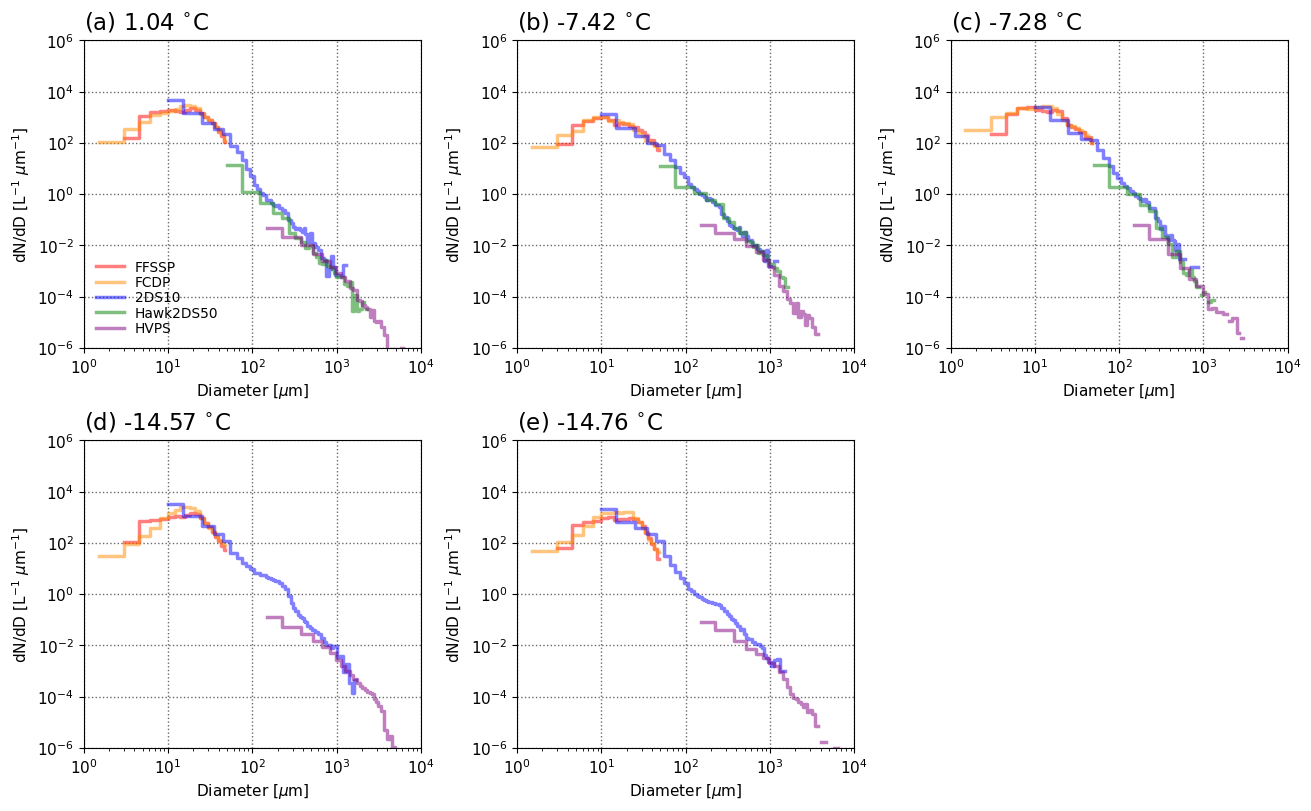

In [26]:
fig = plt.figure(figsize=(13,8),constrained_layout=True)
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)

axlist = [ax1,ax2,ax3,ax4,ax5]
Fontsize=11
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='major',lw=1,c='dimgrey',ls='dotted')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1,1.e4)
    ax.set_ylim(1.e-6,1.e6)
    #ax.set_yticks(10.**np.arange(-8,4,2))
    #ax.set_xticks(10.**np.arange(0,5,1))
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize)
    ax.set_ylabel('dN/dD [L$^{-1}$ $\\mu$m$^{-1}$]',fontsize=Fontsize)

if False:
    dum_y_ticks = np.arange(-8,4,2)
    new_y_ticks = []
    for dum_y_tick in dum_y_ticks:
        new_y_ticks.append('10$^{'+str(int(dum_y_tick))+'}$')
    ax1.set_yticklabels(new_y_ticks)
    #ax3.set_yticklabels(new_y_ticks)
    
    dum_x_ticks = np.arange(0,5,1)
    new_x_ticks = []
    for dum_x_tick in dum_x_ticks:
        new_x_ticks.append('10$^{'+str(int(dum_x_tick))+'}$')
    ax1.set_xticklabels(new_x_ticks)
    ax2.set_xticklabels(new_x_ticks)
    ax3.set_xticklabels(new_x_ticks)

labs = ['(a)','(b)','(c)','(d)','(e)']
dumi=0
for key in top_dict.keys():
    tmp_mean_temp = np.around(top_dict[key]['bulk_dict']['mean_temp'],2)
    dum_str = labs[dumi]+' '+str(tmp_mean_temp)+' $^{\\circ}$C'
    axlist[dumi].text(0,1.1,dum_str,transform=axlist[dumi].transAxes,va='top',ha='left',fontsize=Fontsize*1.5)
    dumi+=1
    
    
dumi=0
for key in top_dict.keys():
    ax = axlist[dumi]
    alpha=0.5
    tmp_lw = 2.5
    #---------------------------------------
    # FFSSP
    #---------------------------------------
    tmp_ffssp_dN = top_dict[key]['dsd_dict']['ffssp']['dsd_native'] # units of #/L/um
    ffssp_sizes = top_dict[key]['dsd_dict']['ffssp']['sizes']
    ffssp_mid_sizes = top_dict[key]['dsd_dict']['ffssp']['mid_sizes']
    tmp_ffssp_dsd = tmp_ffssp_dN
    ax.step(ffssp_mid_sizes,tmp_ffssp_dsd,c='red',lw=tmp_lw,where='mid',alpha=alpha,label='FFSSP')

    #---------------------------------------
    # FCDP
    #---------------------------------------
    tmp_fcdp_dN = top_dict[key]['dsd_dict']['fcdp']['dsd_native'] # units of #/L/um
    fcdp_sizes = top_dict[key]['dsd_dict']['fcdp']['sizes']
    fcdp_mid_sizes = top_dict[key]['dsd_dict']['fcdp']['mid_sizes']
    tmp_fcdp_dsd = tmp_fcdp_dN
    ax.step(fcdp_mid_sizes,tmp_fcdp_dsd,c='darkorange',lw=tmp_lw,where='mid',alpha=alpha,label='FCDP')

    
    #---------------------------------------
    # 2DS10
    #---------------------------------------
    tmp_2ds10_dN = top_dict[key]['dsd_dict']['2ds10']['dsd_native'] # units of #/L/um
    x2ds10_sizes = top_dict[key]['dsd_dict']['2ds10']['sizes']
    x2ds10_mid_sizes = top_dict[key]['dsd_dict']['2ds10']['mid_sizes']
    tmp_2ds10_dsd = tmp_2ds10_dN
    ax.step(x2ds10_mid_sizes,tmp_2ds10_dsd,c='blue',lw=tmp_lw,where='mid',alpha=alpha,label='2DS10')    

    #---------------------------------------
    # Hawkeye 2DS10
    #---------------------------------------
    if False:
        tmp_hawk2ds10_dN = top_dict[key]['dsd_dict']['hawk2ds10']['dsd_native'] # units of #/L/um
        hawk2ds10_sizes = top_dict[key]['dsd_dict']['hawk2ds10']['sizes']
        hawk2ds10_mid_sizes = top_dict[key]['dsd_dict']['hawk2ds10']['mid_sizes']
        tmp_hawk2ds10_dsd = tmp_hawk2ds10_dN
        ax.step(hawk2ds10_mid_sizes,tmp_hawk2ds10_dsd,c='deepskyblue',lw=tmp_lw,where='mid',alpha=alpha,label='Hawk2DS10') 
    
    #---------------------------------------
    # Hawkeye 2DS50
    #---------------------------------------
    tmp_hawk2ds50_dN = top_dict[key]['dsd_dict']['hawk2ds50']['dsd_native'] # units of #/L/um
    hawk2ds50_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['sizes']
    hawk2ds50_mid_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['mid_sizes']
    tmp_hawk2ds50_dsd = tmp_hawk2ds50_dN
    ax.step(hawk2ds50_mid_sizes,tmp_hawk2ds50_dsd,c='green',lw=tmp_lw,where='mid',alpha=alpha,label='Hawk2DS50')        
    
    #---------------------------------------
    # HVPS
    #---------------------------------------
    tmp_hvps_dN = top_dict[key]['dsd_dict']['hvps']['dsd_native'] # units of #/L/um
    hvps_sizes = top_dict[key]['dsd_dict']['hvps']['sizes']
    hvps_mid_sizes = top_dict[key]['dsd_dict']['hvps']['mid_sizes']
    tmp_hvps_dsd = tmp_hvps_dN
    ax.step(hvps_mid_sizes,tmp_hvps_dsd,c='purple',lw=tmp_lw,where='mid',alpha=alpha,label='HVPS')   
    
    
    #---------------------------------------
    # Composite DSD
    #---------------------------------------
    #tmp_comp_dN = comp_dict[key]['dN']
    #tmp_comp_sizes = comp_dict[key]['sizes']
    #tmp_comp_dsd = tmp_comp_dN*1.e-3
    #ax.step(tmp_comp_sizes,tmp_comp_dsd,c='k',lw=1.5,where='mid',alpha=1,label='Composite')
    
    dumi+=1

#ax1.legend(loc='upper right',framealpha=False,fontsize=Fontsize*0.9,bbox_to_anchor=(1.04,1.02),labelspacing=0.1)
ax1.legend(loc='lower left',framealpha=False,fontsize=Fontsize*0.9,bbox_to_anchor=(0,0),labelspacing=0.1)

plt.subplots_adjust(wspace=0.12,hspace=0.125)

plt.show()
plt.close()


# dlogD

## using native calculation of number concentration, then converted to dN/dlogD

/tmp/ipykernel_620961/166975276.py:60: RuntimeWarning: divide by zero encountered in log10
  dlogD = np.diff(np.log10(ffssp_sizes))
/tmp/ipykernel_620961/166975276.py:71: RuntimeWarning: divide by zero encountered in log10
  dlogD = np.diff(np.log10(fcdp_sizes))
/tmp/ipykernel_620961/166975276.py:136: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.12,hspace=0.125)


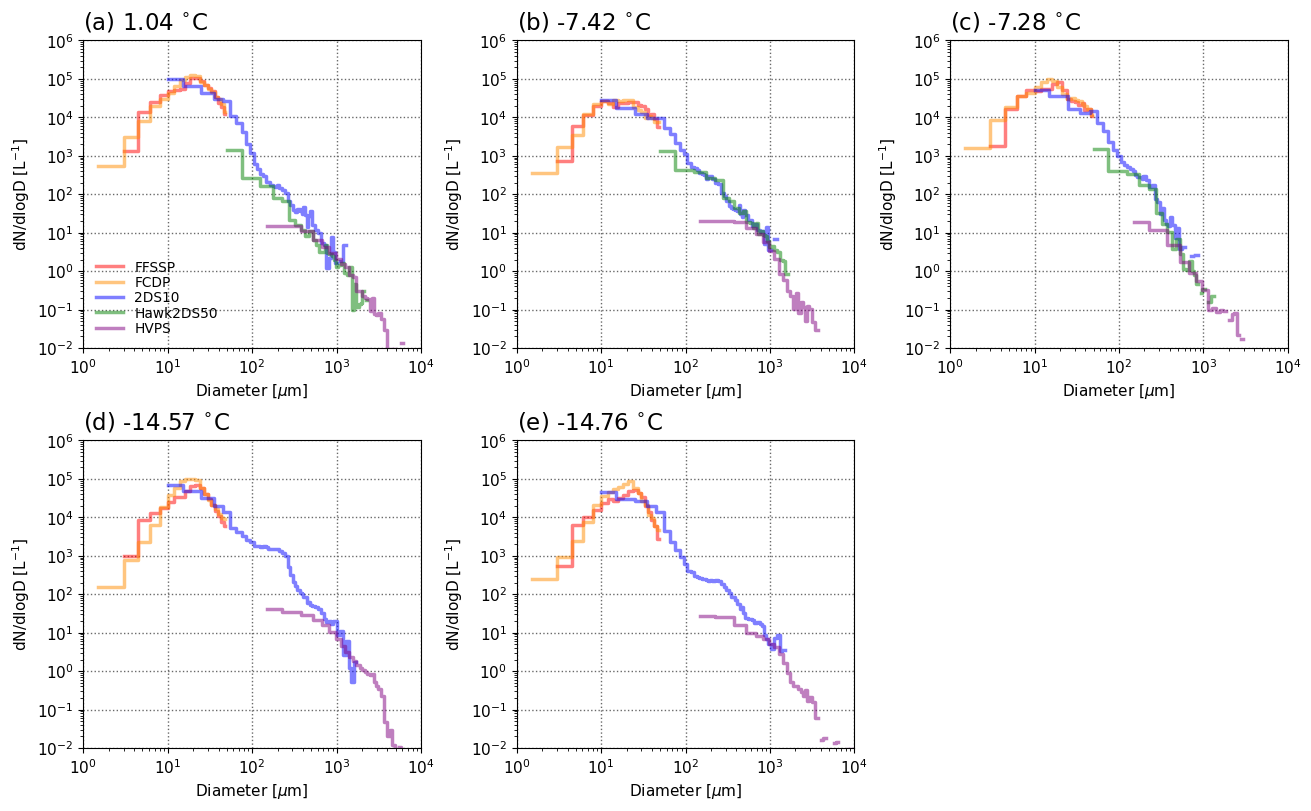

In [27]:
fig = plt.figure(figsize=(13,8),constrained_layout=True)
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)

axlist = [ax1,ax2,ax3,ax4,ax5]
Fontsize=11
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='major',lw=1,c='dimgrey',ls='dotted')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1,1.e4)
    ax.set_ylim(1.e-2,1.e6)
    #ax.set_yticks(10.**np.arange(-8,4,2))
    #ax.set_xticks(10.**np.arange(0,5,1))
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize)
    ax.set_ylabel('dN/dlogD [L$^{-1}$]',fontsize=Fontsize)

if False:
    dum_y_ticks = np.arange(-8,4,2)
    new_y_ticks = []
    for dum_y_tick in dum_y_ticks:
        new_y_ticks.append('10$^{'+str(int(dum_y_tick))+'}$')
    ax1.set_yticklabels(new_y_ticks)
    #ax3.set_yticklabels(new_y_ticks)
    
    dum_x_ticks = np.arange(0,5,1)
    new_x_ticks = []
    for dum_x_tick in dum_x_ticks:
        new_x_ticks.append('10$^{'+str(int(dum_x_tick))+'}$')
    ax1.set_xticklabels(new_x_ticks)
    ax2.set_xticklabels(new_x_ticks)
    ax3.set_xticklabels(new_x_ticks)

labs = ['(a)','(b)','(c)','(d)','(e)']
dumi=0
for key in top_dict.keys():
    tmp_mean_temp = np.around(top_dict[key]['bulk_dict']['mean_temp'],2)
    dum_str = labs[dumi]+' '+str(tmp_mean_temp)+' $^{\\circ}$C'
    axlist[dumi].text(0,1.1,dum_str,transform=axlist[dumi].transAxes,va='top',ha='left',fontsize=Fontsize*1.5)
    dumi+=1
    
    
dumi=0
for key in top_dict.keys():
    ax = axlist[dumi]
    alpha=0.5
    tmp_lw = 2.5
    #---------------------------------------
    # FFSSP
    #---------------------------------------
    tmp_ffssp_dN = top_dict[key]['dsd_dict']['ffssp']['dsd_native'] # units of #/L/um
    ffssp_sizes = top_dict[key]['dsd_dict']['ffssp']['sizes']
    ffssp_mid_sizes = top_dict[key]['dsd_dict']['ffssp']['mid_sizes']
    dlogD = np.diff(np.log10(ffssp_sizes))
    dD = np.diff(ffssp_sizes)
    tmp_ffssp_dsd = tmp_ffssp_dN*dD/dlogD
    ax.step(ffssp_mid_sizes,tmp_ffssp_dsd,c='red',lw=tmp_lw,where='mid',alpha=alpha,label='FFSSP')

    #---------------------------------------
    # FCDP
    #---------------------------------------
    tmp_fcdp_dN = top_dict[key]['dsd_dict']['fcdp']['dsd_native'] # units of #/L/um
    fcdp_sizes = top_dict[key]['dsd_dict']['fcdp']['sizes']
    fcdp_mid_sizes = top_dict[key]['dsd_dict']['fcdp']['mid_sizes']
    dlogD = np.diff(np.log10(fcdp_sizes))
    dD = np.diff(fcdp_sizes)
    tmp_fcdp_dsd = tmp_fcdp_dN*dD/dlogD
    ax.step(fcdp_mid_sizes,tmp_fcdp_dsd,c='darkorange',lw=tmp_lw,where='mid',alpha=alpha,label='FCDP')

    
    #---------------------------------------
    # 2DS10
    #---------------------------------------
    tmp_2ds10_dN = top_dict[key]['dsd_dict']['2ds10']['dsd_native'] # units of #/L/um
    x2ds10_sizes = top_dict[key]['dsd_dict']['2ds10']['sizes']
    x2ds10_mid_sizes = top_dict[key]['dsd_dict']['2ds10']['mid_sizes']
    dlogD = np.diff(np.log10(x2ds10_sizes))
    dD = np.diff(x2ds10_sizes)
    tmp_2ds10_dsd = tmp_2ds10_dN*dD/dlogD
    ax.step(x2ds10_mid_sizes,tmp_2ds10_dsd,c='blue',lw=tmp_lw,where='mid',alpha=alpha,label='2DS10')    

    #---------------------------------------
    # Hawkeye 2DS10
    #---------------------------------------
    if False:
        tmp_hawk2ds10_dN = top_dict[key]['dsd_dict']['hawk2ds10']['dsd_native'] # units of #/L/um
        hawk2ds10_sizes = top_dict[key]['dsd_dict']['hawk2ds10']['sizes']
        hawk2ds10_mid_sizes = top_dict[key]['dsd_dict']['hawk2ds10']['mid_sizes']
        dlogD = np.diff(np.log10(x2ds10_sizes))
        dD = np.diff(x2ds10_sides)
        tmp_hawk2ds10_dsd = tmp_hawk2ds10_dN*dD/dlogD
        ax.step(hawk2ds10_mid_sizes,tmp_hawk2ds10_dsd,c='deepskyblue',lw=tmp_lw,where='mid',alpha=alpha,label='Hawk2DS10') 
    
    #---------------------------------------
    # Hawkeye 2DS50
    #---------------------------------------
    tmp_hawk2ds50_dN = top_dict[key]['dsd_dict']['hawk2ds50']['dsd_native'] # units of #/L/um
    hawk2ds50_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['sizes']
    hawk2ds50_mid_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['mid_sizes']
    dlogD = np.diff(np.log10(hawk2ds50_sizes))
    dD = np.diff(hawk2ds50_sizes)
    tmp_hawk2ds50_dsd = tmp_hawk2ds50_dN*dD/dlogD
    ax.step(hawk2ds50_mid_sizes,tmp_hawk2ds50_dsd,c='green',lw=tmp_lw,where='mid',alpha=alpha,label='Hawk2DS50')        
    
    #---------------------------------------
    # HVPS
    #---------------------------------------
    tmp_hvps_dN = top_dict[key]['dsd_dict']['hvps']['dsd_native'] # units of #/L/um
    hvps_sizes = top_dict[key]['dsd_dict']['hvps']['sizes']
    hvps_mid_sizes = top_dict[key]['dsd_dict']['hvps']['mid_sizes']
    dlogD = np.diff(np.log10(hvps_sizes))
    dD = np.diff(hvps_sizes)
    tmp_hvps_dsd = tmp_hvps_dN*dD/dlogD
    ax.step(hvps_mid_sizes,tmp_hvps_dsd,c='purple',lw=tmp_lw,where='mid',alpha=alpha,label='HVPS')   
    
    
    #---------------------------------------
    # Composite DSD
    #---------------------------------------
    #tmp_comp_dN = comp_dict[key]['dN']
    #tmp_comp_sizes = comp_dict[key]['sizes']
    #tmp_comp_dsd = tmp_comp_dN*1.e-3
    #ax.step(tmp_comp_sizes,tmp_comp_dsd,c='k',lw=1.5,where='mid',alpha=1,label='Composite')
    
    dumi+=1

#ax1.legend(loc='upper right',framealpha=False,fontsize=Fontsize*0.9,bbox_to_anchor=(1.04,1.02),labelspacing=0.1)
ax1.legend(loc='lower left',framealpha=False,fontsize=Fontsize*0.9,bbox_to_anchor=(0,0),labelspacing=0.1)

plt.subplots_adjust(wspace=0.12,hspace=0.125)

plt.show()
plt.close()


# Choose split sizes for stitching together instruments

In [28]:
split_dict = {}
dumi = 0
for key in top_dict.keys():
    split_dict[key] = {}

    if dumi == 0.:
        split1 = 50
        split2 = 550
    if dumi == 1.:
        split1 = 50
        split2 = 1000
        #split3 = 250
        
    if dumi == 2.:
        split1 = 50
        split2 = 600
        #split3 = 400
        
    if dumi == 3.:
        split1 = 50
        split2 = 1000
        #split3 = 500

    if dumi == 4:
        split1 = 50
        split2 = 1000
        #split3 = 
        

        
    split_dict[key]['split1'] = split1
    split_dict[key]['split2'] = split2
    #split_dict[key]['split3'] = split3
    
    dumi+=1

# Make composite distributions

In [29]:
comp_dict = {}


for key in top_dict.keys():
    
    comp_dict[key] = {}
    
    tmp_ffssp_dN = top_dict[key]['dsd_dict']['ffssp']['dsd_native'] # dN/dD in units of #/L/um
    ffssp_sizes = top_dict[key]['dsd_dict']['ffssp']['sizes']
    ffssp_mid_sizes = top_dict[key]['dsd_dict']['ffssp']['mid_sizes']
    ffssp_dlogD = np.diff(np.log10(ffssp_sizes))
    ffssp_dD = np.diff(ffssp_sizes)
    tmp_ffssp_dN = tmp_ffssp_dN*ffssp_dD

    tmp_2ds10_dN = top_dict[key]['dsd_dict']['2ds10']['dsd_native'] # dN/dD in units of #/L/um
    x2ds10_sizes = top_dict[key]['dsd_dict']['2ds10']['sizes']
    x2ds10_mid_sizes = top_dict[key]['dsd_dict']['2ds10']['mid_sizes']
    x2ds10_dlogD = np.diff(np.log10(x2ds10_sizes))
    x2ds10_dD = np.diff(x2ds10_sizes)
    tmp_2ds10_dN = tmp_2ds10_dN*x2ds10_dD
    
    tmp_hawk2ds50_dN = top_dict[key]['dsd_dict']['hawk2ds50']['dsd_native'] # dN/dD in units of #/L/um
    hawk2ds50_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['sizes']
    hawk2ds50_mid_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['mid_sizes']
    hawk2ds50_dlogD = np.diff(np.log10(hawk2ds50_sizes))
    hawk2ds50_dD = np.diff(hawk2ds50_sizes)
    tmp_hawk2ds50_dN = tmp_hawk2ds50_dN*hawk2ds50_dD
    
    tmp_hvps_dN = top_dict[key]['dsd_dict']['hvps']['dsd_native'] # dN/dD in units of #/L/um
    hvps_sizes = top_dict[key]['dsd_dict']['hvps']['sizes']
    hvps_mid_sizes = top_dict[key]['dsd_dict']['hvps']['mid_sizes']
    hvps_dlogD = np.diff(np.log10(hvps_sizes))
    hvps_dD = np.diff(hvps_sizes)
    tmp_hvps_dN = tmp_hvps_dN*hvps_dD
    
    split1_size = split_dict[key]['split1']
    split2_size = split_dict[key]['split2']
    #split3_size = split_dict[key]['split3']
    
    
    split1_id = np.where(ffssp_mid_sizes <= split1_size)[0][:-1]
    split2_id = np.where((x2ds10_mid_sizes > split1_size) & (x2ds10_mid_sizes <= split2_size) )[0][:-1]
    #split3_id = np.where((hawkeye_2ds50_mid_sizes > split2_size) & (hawkeye_2ds50_mid_sizes <= split3_size) )[0][:-1]
    split3_id = np.where(hvps_mid_sizes > split2_size )[0][:-1]
    
    comp_dN = []
    comp_sizes = []
    comp_dlogD = []
    comp_dD = []
    
    comp_dN.append(tmp_ffssp_dN[split1_id])
    comp_sizes.append(ffssp_mid_sizes[split1_id])
    comp_dlogD.append(ffssp_dlogD[split1_id])
    comp_dD.append(ffssp_dD[split1_id])
    
    comp_dN.append(tmp_2ds10_dN[split2_id])
    comp_sizes.append(x2ds10_mid_sizes[split2_id])
    comp_dlogD.append(x2ds10_dlogD[split2_id])
    comp_dD.append(x2ds10_dD[split2_id])
    
    #comp_dN.append(tmp_hawk2ds50_dN[split3_id])
    #comp_sizes.append(hawk2ds50_mid_sizes[split3_id])
    #comp_dlogD.append(hawk2ds50_dlogD[split3_id])
    #comp_dD.append(hawk2ds50_dD[split3_id])
    
    comp_dN.append(tmp_hvps_dN[split3_id])
    comp_sizes.append(hvps_mid_sizes[split3_id])
    comp_dlogD.append(hvps_dlogD[split3_id])
    comp_dD.append(hvps_dD[split3_id])
    
    comp_dN = np.concatenate(comp_dN)
    comp_sizes = np.concatenate(comp_sizes) 
    comp_dlogD = np.concatenate(comp_dlogD)
    comp_dD = np.concatenate(comp_dD)
    
    
    if False:
        # Interpolate to grid with common spacing
        interp_sizes = np.arange(1,10001,1)
        f = interp.interp1d(comp_sizes,comp_dN,kind='nearest',fill_value=np.nan,bounds_error=False)     
        comp_dN_interp = f(interp_sizes)   

        mid_interp_sizes = np.array([0.5*(interp_sizes[dd] + interp_sizes[dd+1]) for dd in range(len(interp_sizes)-1)])
        mid_interp_sizes = np.concatenate([np.array([0.5]),mid_interp_sizes,np.array([10000.5])])

        comp_dict[key]['dsd_interp'] = comp_dN_interp
        comp_dict[key]['interp_sizes'] = interp_sizes
        comp_dict[key]['mid_interp_sizes'] = mid_interp_sizes 
    
    
    comp_dict[key]['dN'] = comp_dN
    comp_dict[key]['dNdD'] = comp_dN/comp_dD
    comp_dict[key]['dNdlogD'] = comp_dN/comp_dlogD
    comp_dict[key]['sizes'] = comp_sizes
    comp_dict[key]['dlogD'] = comp_dlogD
    comp_dict[key]['dD'] = comp_dD
    top_dict[key]['comp'] = comp_dict[key]
    
    
    #print(aaaaa)

/tmp/ipykernel_620961/3499836301.py:11: RuntimeWarning: divide by zero encountered in log10
  ffssp_dlogD = np.diff(np.log10(ffssp_sizes))


# Plot dN/dD figure

/tmp/ipykernel_620961/1618600038.py:107: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1,hspace=0.125)


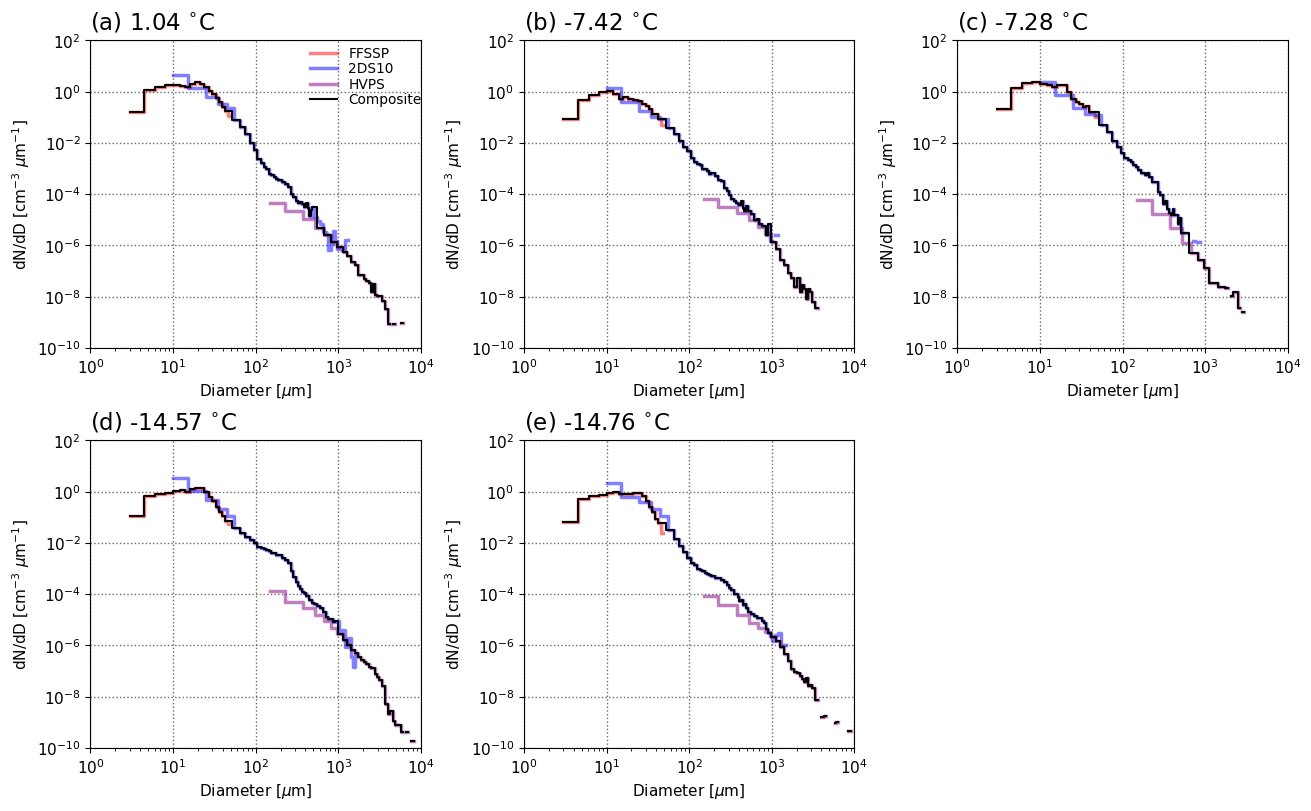

In [30]:
fig = plt.figure(figsize=(13,8),constrained_layout=True)
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)

axlist = [ax1,ax2,ax3,ax4,ax5]
Fontsize=11
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='major',lw=1,c='dimgrey',ls='dotted')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1,1.e4)
    ax.set_ylim(1.e-10,1.e2)
    ax.set_yticks(10.**np.arange(-10,4,2))
    ax.set_xticks(10.**np.arange(0,5,1))
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])
    #ax.minorticks_on
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize)
    ax.set_ylabel('dN/dD [cm$^{-3}$ $\\mu$m$^{-1}$]',fontsize=Fontsize)

if False:
    dum_y_ticks = np.arange(-10,4,2)
    new_y_ticks = []
    for dum_y_tick in dum_y_ticks:
        new_y_ticks.append('10$^{'+str(int(dum_y_tick))+'}$')
    ax1.set_yticklabels(new_y_ticks)
    #ax3.set_yticklabels(new_y_ticks)
    
    dum_x_ticks = np.arange(0,5,1)
    new_x_ticks = []
    for dum_x_tick in dum_x_ticks:
        new_x_ticks.append('10$^{'+str(int(dum_x_tick))+'}$')
    ax1.set_xticklabels(new_x_ticks)
    ax2.set_xticklabels(new_x_ticks)
    ax3.set_xticklabels(new_x_ticks)

labs = ['(a)','(b)','(c)','(d)','(e)']
dumi=0
for key in top_dict.keys():
    tmp_mean_temp = np.around(top_dict[key]['bulk_dict']['mean_temp'],2)
    dum_str = labs[dumi]+' '+str(tmp_mean_temp)+' $^{\\circ}$C'
    axlist[dumi].text(0,1.1,dum_str,transform=axlist[dumi].transAxes,va='top',ha='left',fontsize=Fontsize*1.5)
    dumi+=1
    
    
dumi=0
for key in top_dict.keys():
    ax = axlist[dumi]
    alpha=0.5
    tmp_lw = 2.5
    #---------------------------------------
    # FFSSP
    #---------------------------------------
    tmp_ffssp_dN = top_dict[key]['dsd_dict']['ffssp']['dsd_native'] # dN/dD in units of #/L/um
    ffssp_sizes = top_dict[key]['dsd_dict']['ffssp']['sizes']
    ffssp_mid_sizes = top_dict[key]['dsd_dict']['ffssp']['mid_sizes']
    tmp_ffssp_dsd = tmp_ffssp_dN*1.e-3
    ax.step(ffssp_mid_sizes,tmp_ffssp_dsd,c='red',lw=tmp_lw,where='mid',alpha=alpha,label='FFSSP')

    #---------------------------------------
    # 2DS10
    #---------------------------------------
    tmp_2ds10_dN = top_dict[key]['dsd_dict']['2ds10']['dsd_native'] # dN/dD in units of #/L/um
    x2ds10_sizes = top_dict[key]['dsd_dict']['2ds10']['sizes']
    x2ds10_mid_sizes = top_dict[key]['dsd_dict']['2ds10']['mid_sizes']
    tmp_2ds10_dsd = tmp_2ds10_dN*1.e-3
    ax.step(x2ds10_mid_sizes,tmp_2ds10_dsd,c='blue',lw=tmp_lw,where='mid',alpha=alpha,label='2DS10')    
    
    #---------------------------------------
    # Hawkeye 2DS50
    #---------------------------------------
    #tmp_hawk2ds50_dN = top_dict[key]['dsd_dict']['hawk2ds50']['dsd_native'] # dN/dD in units of #/L/um
    #hawk2ds50_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['sizes']
    #hawk2ds50_mid_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['mid_sizes']
    #tmp_hawk2ds50_dsd = tmp_hawk2ds50_dN*1.e-3
    #ax.step(hawk2ds50_mid_sizes,tmp_hawk2ds50_dsd,c='green',lw=tmp_lw,where='mid',alpha=alpha,label='Hawk2DS50')        
    
    #---------------------------------------
    # HVPS
    #---------------------------------------
    tmp_hvps_dN = top_dict[key]['dsd_dict']['hvps']['dsd_native'] # dN/dD in units of #/L/um
    hvps_sizes = top_dict[key]['dsd_dict']['hvps']['sizes']
    hvps_mid_sizes = top_dict[key]['dsd_dict']['hvps']['mid_sizes']
    tmp_hvps_dsd = tmp_hvps_dN*1.e-3
    ax.step(hvps_mid_sizes,tmp_hvps_dsd,c='purple',lw=tmp_lw,where='mid',alpha=alpha,label='HVPS')   
    
    
    #---------------------------------------
    # Composite DSD
    #---------------------------------------
    #tmp_comp_dN = comp_dict[key]['dN']
    tmp_comp_dNdD = comp_dict[key]['dNdD']*1.e-3
    tmp_comp_sizes = comp_dict[key]['sizes']
    #dD = comp_dict[key]['dD']
    #tmp_comp_dsd = tmp_comp_dN*1.e-3/dD
    #ax.step(tmp_comp_sizes,tmp_comp_dsd,c='k',lw=1.5,where='mid',alpha=1,label='Composite')
    ax.step(tmp_comp_sizes,tmp_comp_dNdD,c='k',lw=1.5,where='mid',alpha=1,label='Composite')
    
    dumi+=1

ax1.legend(loc='upper right',framealpha=False,fontsize=Fontsize*0.9,bbox_to_anchor=(1.04,1.02),labelspacing=0.1)

plt.subplots_adjust(wspace=0.1,hspace=0.125)

plt.show()
plt.close()


# Plot dN/dlogD figure

/tmp/ipykernel_620961/2017506744.py:61: RuntimeWarning: divide by zero encountered in log10
  dlogD = np.diff(np.log10(ffssp_sizes))
/tmp/ipykernel_620961/2017506744.py:115: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1,hspace=0.125)


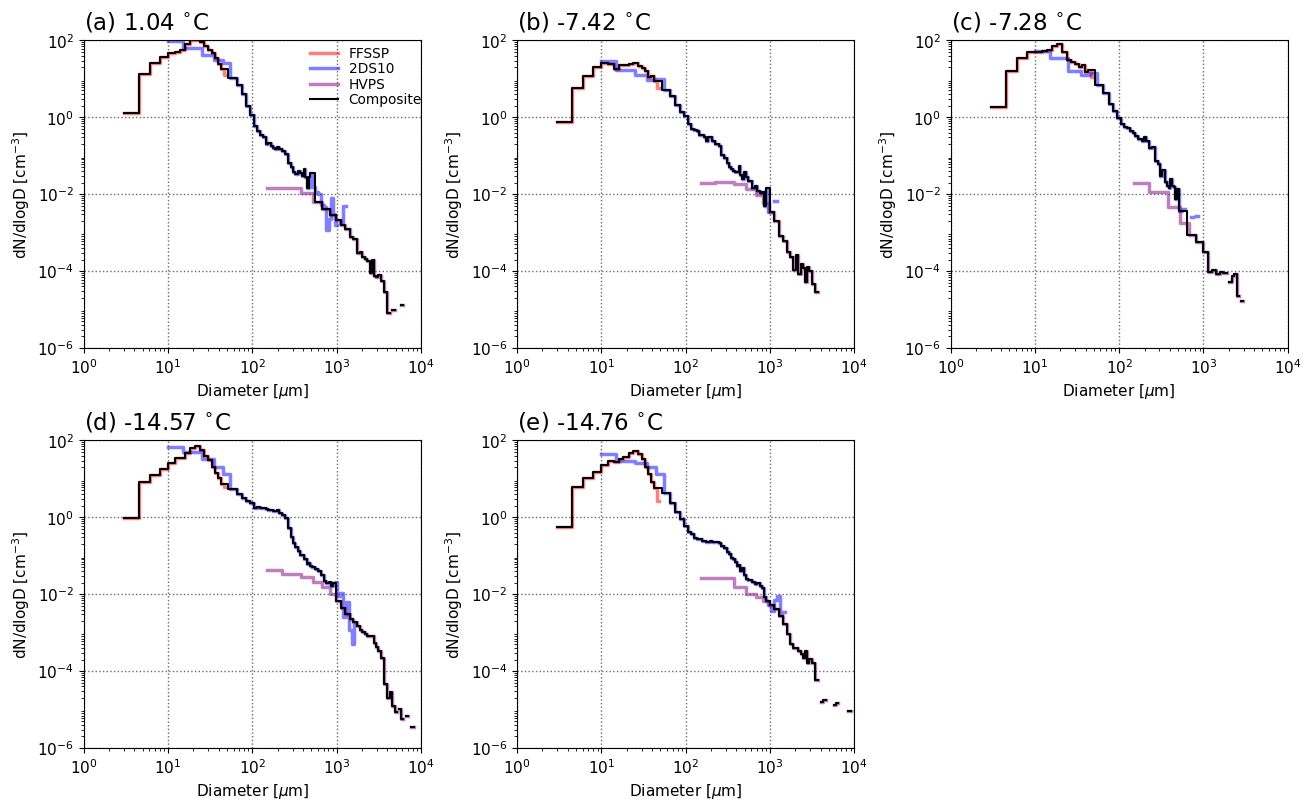

In [31]:
fig = plt.figure(figsize=(13,8),constrained_layout=True)
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)

axlist = [ax1,ax2,ax3,ax4,ax5]
Fontsize=11
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='major',lw=1,c='dimgrey',ls='dotted')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1,1.e4)
    ax.set_ylim(1.e-6,1.e2)
    ax.set_yticks(10.**np.arange(-6,4,2))
    ax.set_xticks(10.**np.arange(0,5,1))
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])
    #ax.minorticks_on
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize)

if False:
    dum_y_ticks = np.arange(-6,6,2)
    new_y_ticks = []
    for dum_y_tick in dum_y_ticks:
        new_y_ticks.append('10$^{'+str(int(dum_y_tick))+'}$')
    ax1.set_yticklabels(new_y_ticks)
    #ax3.set_yticklabels(new_y_ticks)
    
    dum_x_ticks = np.arange(0,5,1)
    new_x_ticks = []
    for dum_x_tick in dum_x_ticks:
        new_x_ticks.append('10$^{'+str(int(dum_x_tick))+'}$')
    ax1.set_xticklabels(new_x_ticks)
    ax2.set_xticklabels(new_x_ticks)
    ax3.set_xticklabels(new_x_ticks)

labs = ['(a)','(b)','(c)','(d)','(e)']
dumi=0
for key in top_dict.keys():
    tmp_mean_temp = np.around(top_dict[key]['bulk_dict']['mean_temp'],2)
    dum_str = labs[dumi]+' '+str(tmp_mean_temp)+' $^{\\circ}$C'
    axlist[dumi].text(0,1.1,dum_str,transform=axlist[dumi].transAxes,va='top',ha='left',fontsize=Fontsize*1.5)
    dumi+=1
    
    
dumi=0
for key in top_dict.keys():
    ax = axlist[dumi]
    alpha=0.5
    tmp_lw = 2.5
    #---------------------------------------
    # FFSSP
    #---------------------------------------
    tmp_ffssp_dN = top_dict[key]['dsd_dict']['ffssp']['dsd_native'] # dN/dD in units of #/L/um
    ffssp_sizes = top_dict[key]['dsd_dict']['ffssp']['sizes']
    ffssp_mid_sizes = top_dict[key]['dsd_dict']['ffssp']['mid_sizes']
    dlogD = np.diff(np.log10(ffssp_sizes))
    dD = np.diff(ffssp_sizes)
    tmp_ffssp_dsd = tmp_ffssp_dN*dD*1.e-3/dlogD
    ax.step(ffssp_mid_sizes,tmp_ffssp_dsd,c='red',lw=tmp_lw,where='mid',alpha=alpha,label='FFSSP')

    #---------------------------------------
    # 2DS10
    #---------------------------------------
    tmp_2ds10_dN = top_dict[key]['dsd_dict']['2ds10']['dsd_native'] # dN/dD in units of #/L/um
    x2ds10_sizes = top_dict[key]['dsd_dict']['2ds10']['sizes']
    x2ds10_mid_sizes = top_dict[key]['dsd_dict']['2ds10']['mid_sizes']
    dlogD = np.diff(np.log10(x2ds10_sizes))
    dD = np.diff(x2ds10_sizes)
    tmp_2ds10_dsd = tmp_2ds10_dN*dD*1.e-3/dlogD
    ax.step(x2ds10_mid_sizes,tmp_2ds10_dsd,c='blue',lw=tmp_lw,where='mid',alpha=alpha,label='2DS10')    
    
    #---------------------------------------
    # Hawkeye 2DS50
    #---------------------------------------
    #tmp_hawk2ds50_dN = top_dict[key]['dsd_dict']['hawk2ds50']['dsd_native'] # dN/dD in units of #/L/um
    #hawk2ds50_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['sizes']
    #hawk2ds50_mid_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['mid_sizes']
    #dlogD = np.diff(np.log10(hawk2ds50_sizes))
    #dD = np.diff(hawk2ds50_sizes)
    #tmp_hawk2ds50_dsd = tmp_hawk2ds50_dN*dD*1.e-3/dlogD
    #ax.step(hawk2ds50_mid_sizes,tmp_hawk2ds50_dsd,c='green',lw=tmp_lw,where='mid',alpha=alpha,label='Hawk2DS50')        
    
    #---------------------------------------
    # HVPS
    #---------------------------------------
    tmp_hvps_dN = top_dict[key]['dsd_dict']['hvps']['dsd_native'] # dN/dD in units of #/L/um
    hvps_sizes = top_dict[key]['dsd_dict']['hvps']['sizes']
    hvps_mid_sizes = top_dict[key]['dsd_dict']['hvps']['mid_sizes']
    dlogD = np.diff(np.log10(hvps_sizes))
    dD = np.diff(hvps_sizes)
    tmp_hvps_dsd = tmp_hvps_dN*dD*1.e-3/dlogD
    ax.step(hvps_mid_sizes,tmp_hvps_dsd,c='purple',lw=tmp_lw,where='mid',alpha=alpha,label='HVPS')   
    
    
    #---------------------------------------
    # Composite DSD
    #---------------------------------------
    #tmp_comp_dN = comp_dict[key]['dsd']
    tmp_comp_dNdlogD = comp_dict[key]['dNdlogD']*1.e-3
    tmp_comp_sizes = comp_dict[key]['sizes']
    #dlogD = comp_dict[key]['dlogD']
    #tmp_comp_dsd = tmp_comp_dN*1.e-3/dlogD
    #ax.step(tmp_comp_sizes,tmp_comp_dsd,c='k',lw=1.5,where='mid',alpha=1,label='Composite')
    ax.step(tmp_comp_sizes,tmp_comp_dNdlogD,c='k',lw=1.5,where='mid',alpha=1,label='Composite')
    
    dumi+=1

ax1.legend(loc='upper right',framealpha=False,fontsize=Fontsize*0.9,bbox_to_anchor=(1.04,1.02),labelspacing=0.1)

plt.subplots_adjust(wspace=0.1,hspace=0.125)

save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'learjet_dsd_4_cloud_passes.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()



/tmp/ipykernel_620961/3947163706.py:120: RuntimeWarning: divide by zero encountered in log10
  dlogD = np.diff(np.log10(ffssp_sizes))


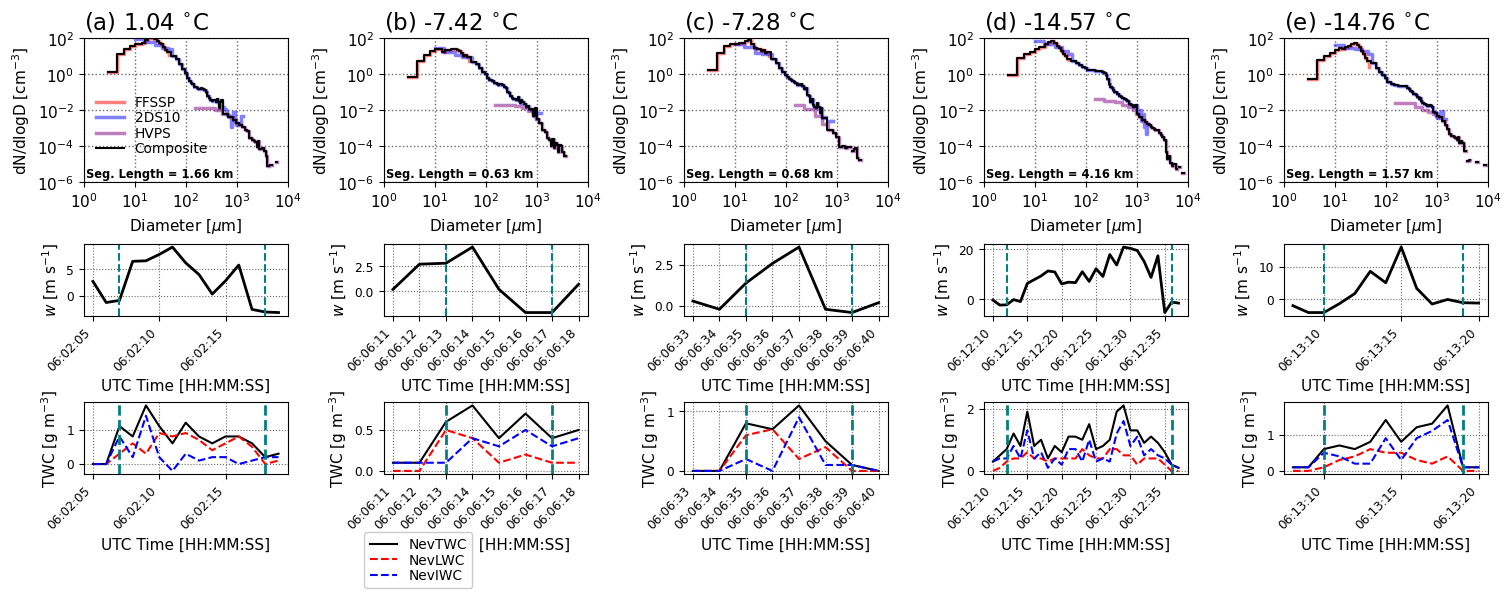

In [32]:
fig = plt.figure(figsize=(15, 5.5), constrained_layout=True)
gs = GridSpec(3, 5, figure=fig, height_ratios=[2, 1, 1])  # Top row twice as high as the bottom two

# Top row (main plots)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])
ax5 = fig.add_subplot(gs[0, 4])

# Bottom two rows (smaller subplots below each main plot)
ax1_1 = fig.add_subplot(gs[1, 0])
ax1_2 = fig.add_subplot(gs[2, 0])
ax2_1 = fig.add_subplot(gs[1, 1])
ax2_2 = fig.add_subplot(gs[2, 1])
ax3_1 = fig.add_subplot(gs[1, 2])
ax3_2 = fig.add_subplot(gs[2, 2])
ax4_1 = fig.add_subplot(gs[1, 3])
ax4_2 = fig.add_subplot(gs[2, 3])
ax5_1 = fig.add_subplot(gs[1, 4])
ax5_2 = fig.add_subplot(gs[2, 4])

axlist = [ax1, ax2, ax3, ax4,ax5]
Fontsize = 11
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='major', lw=1, c='dimgrey', ls='dotted')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1, 1.e4)
    ax.set_ylim(1.e-6, 1.e2)
    ax.set_yticks(10.**np.arange(-6, 4, 2))
    ax.set_xticks(10.**np.arange(0, 5, 1))
    ax.set_xlabel('Diameter [$\\mu$m]', fontsize=Fontsize)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]', fontsize=Fontsize)

# You can customize the smaller subplots (ax1_1, ax1_2, etc.) similarly
for ax in [ax1_1, ax1_2, ax2_1, ax2_2, ax3_1, ax3_2, ax4_1, ax4_2, ax5_1, ax5_2]:
    ax.tick_params(labelsize=Fontsize*0.8)
    ax.grid(which='major', lw=0.8, c='dimgrey', ls='dotted')
    #ax.set_xscale('log')
    #ax.set_yscale('log')
    #ax.set_xlim(1, 1.e4)
    #ax.set_ylim(1.e-6, 1.e2)

axlist2 = [ax1_1,ax2_1,ax3_1,ax4_1,ax5_1]
axlist3 = [ax1_2,ax2_2,ax3_2,ax4_2,ax5_2]

for ax in axlist2:
    ax.set_xlabel('UTC Time [HH:MM:SS]',fontsize=Fontsize)
    ax.set_ylabel('$w$ [m s$^{-1}$]',fontsize=Fontsize)
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M:%S')) 
    #ax.tick_params(axis='x', rotation=45)


for ax in axlist3:
    ax.set_xlabel('UTC Time [HH:MM:SS]',fontsize=Fontsize)
    ax.set_ylabel('TWC [g m$^{-3}$]',fontsize=Fontsize)
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M:%S')) 
    #ax.tick_params(axis='x', rotation=45)

for ax in axlist2:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')  # Aligns the right edge of the text to the tick mark
        #label.set_va('top')  # Aligns the right edge of the text to the tick mark
for ax in axlist3:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')  # Aligns the right edge of the text to the tick mark
        #label.set_va('top')  # Aligns the right edge of the text to the tick mark

labs = ['(a)','(b)','(c)','(d)','(e)']
dumi=0
for key in top_dict.keys():
    tmp_mean_temp = np.around(top_dict[key]['bulk_dict']['mean_temp'],2)
    dum_str = labs[dumi]+' '+str(tmp_mean_temp)+' $^{\\circ}$C'
    axlist[dumi].text(0,1.2,dum_str,transform=axlist[dumi].transAxes,va='top',ha='left',fontsize=Fontsize*1.5)
    dumi+=1

dumi=0
for key in top_dict.keys():
    ax = axlist2[dumi]
    dumi+=1
    
dumi=0
for key in top_dict.keys():
    ax = axlist[dumi]

    #---------------------------------------
    # vertical velocity
    #---------------------------------------
    ax_w = axlist2[dumi]
    ax_w.plot(top_dict[key]['bulk_dict']['time'],top_dict[key]['bulk_dict']['w'],lw=2,c='k')
    ax_w.axvline(top_dict[key]['bulk_dict']['seg_start_time'],lw=1.5,c='teal',ls='dashed',label='Start Time')
    ax_w.axvline(top_dict[key]['bulk_dict']['seg_end_time'],lw=1.5,c='teal',ls='dashed',label='End Time')


    #---------------------------------------
    # WC
    #---------------------------------------
    ax_wc = axlist3[dumi]
    ax_wc.plot(top_dict[key]['bulk_dict']['time'],top_dict[key]['bulk_dict']['NevTWC'],lw=1.5,c='k',label='NevTWC')
    ax_wc.plot(top_dict[key]['bulk_dict']['time'],top_dict[key]['bulk_dict']['NevLWC'],lw=1.5,c='red',label='NevLWC',ls='dashed')
    ax_wc.plot(top_dict[key]['bulk_dict']['time'],top_dict[key]['bulk_dict']['NevTWC']-top_dict[key]['bulk_dict']['NevLWC'],lw=1.5,c='blue',label='NevIWC',ls='dashed')
    ax_wc.axvline(top_dict[key]['bulk_dict']['seg_start_time'],lw=2,c='teal',ls='dashed',label='Start Time')
    ax_wc.axvline(top_dict[key]['bulk_dict']['seg_end_time'],lw=2,c='teal',ls='dashed',label='End Time')
    #ax_wc.plot(top_dict[key]['bulk_dict']['time'],top_dict[key]['bulk_dict']['lwc'],lw=1,c='r',label='ProbeLWC',ls='dashed')
    #ax_wc.plot(top_dict[key]['bulk_dict']['time'],top_dict[key]['bulk_dict']['iwc'],lw=1,c='blue',label='ProbeIWC',ls='dashed')
    #ax_wc.plot(top_dict[key]['bulk_dict']['time'],top_dict[key]['bulk_dict']['lwc']+top_dict[key]['bulk_dict']['iwc'],lw=1,c='k',label='ProbeTWC')
    
    alpha=0.5
    tmp_lw = 2.5
    #---------------------------------------
    # FFSSP
    #---------------------------------------
    tmp_ffssp_dN = top_dict[key]['dsd_dict']['ffssp']['dsd_native'] # dN/dD in units of #/L/um
    ffssp_sizes = top_dict[key]['dsd_dict']['ffssp']['sizes']
    ffssp_mid_sizes = top_dict[key]['dsd_dict']['ffssp']['mid_sizes']
    dlogD = np.diff(np.log10(ffssp_sizes))
    dD = np.diff(ffssp_sizes)
    tmp_ffssp_dsd = tmp_ffssp_dN*dD*1.e-3/dlogD
    ax.step(ffssp_mid_sizes,tmp_ffssp_dsd,c='red',lw=tmp_lw,where='mid',alpha=alpha,label='FFSSP')

    #---------------------------------------
    # 2DS10
    #---------------------------------------
    tmp_2ds10_dN = top_dict[key]['dsd_dict']['2ds10']['dsd_native'] # dN/dD in units of #/L/um
    x2ds10_sizes = top_dict[key]['dsd_dict']['2ds10']['sizes']
    x2ds10_mid_sizes = top_dict[key]['dsd_dict']['2ds10']['mid_sizes']
    dlogD = np.diff(np.log10(x2ds10_sizes))
    dD = np.diff(x2ds10_sizes)
    tmp_2ds10_dsd = tmp_2ds10_dN*dD*1.e-3/dlogD
    ax.step(x2ds10_mid_sizes,tmp_2ds10_dsd,c='blue',lw=tmp_lw,where='mid',alpha=alpha,label='2DS10')    
    
    #---------------------------------------
    # Hawkeye 2DS50
    #---------------------------------------
    #tmp_hawk2ds50_dN = top_dict[key]['dsd_dict']['hawk2ds50']['dsd_native'] # dN/dD in units of #/L/um
    #hawk2ds50_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['sizes']
    #hawk2ds50_mid_sizes = top_dict[key]['dsd_dict']['hawk2ds50']['mid_sizes']
    #dlogD = np.diff(np.log10(hawk2ds50_sizes))
    #dD = np.diff(hawk2ds50_sizes)
    #tmp_hawk2ds50_dsd = tmp_hawk2ds50_dN*dD*1.e-3/dlogD
    #ax.step(hawk2ds50_mid_sizes,tmp_hawk2ds50_dsd,c='green',lw=tmp_lw,where='mid',alpha=alpha,label='Hawk2DS50')        
    
    #---------------------------------------
    # HVPS
    #---------------------------------------
    tmp_hvps_dN = top_dict[key]['dsd_dict']['hvps']['dsd_native'] # dN/dD in units of #/L/um
    hvps_sizes = top_dict[key]['dsd_dict']['hvps']['sizes']
    hvps_mid_sizes = top_dict[key]['dsd_dict']['hvps']['mid_sizes']
    dlogD = np.diff(np.log10(hvps_sizes))
    dD = np.diff(hvps_sizes)
    tmp_hvps_dsd = tmp_hvps_dN*dD*1.e-3/dlogD
    ax.step(hvps_mid_sizes,tmp_hvps_dsd,c='purple',lw=tmp_lw,where='mid',alpha=alpha,label='HVPS')   
    
    
    #---------------------------------------
    # Composite DSD
    #---------------------------------------
    #tmp_comp_dN = comp_dict[key]['dsd']
    tmp_comp_dNdlogD = comp_dict[key]['dNdlogD']*1.e-3
    tmp_comp_sizes = comp_dict[key]['sizes']
    #dlogD = comp_dict[key]['dlogD']
    #tmp_comp_dsd = tmp_comp_dN*1.e-3/dlogD
    #ax.step(tmp_comp_sizes,tmp_comp_dsd,c='k',lw=1.5,where='mid',alpha=1,label='Composite')
    ax.step(tmp_comp_sizes,tmp_comp_dNdlogD,c='k',lw=1.5,where='mid',alpha=1,label='Composite')
    
    dumi+=1

#ax1.legend(loc='upper right',framealpha=False,fontsize=Fontsize*0.9,bbox_to_anchor=(1.04,1.02),labelspacing=0.1)
ax1.legend(loc='lower left',framealpha=False,fontsize=Fontsize*0.9,bbox_to_anchor=(0.,0.1),labelspacing=0.1)

#plt.subplots_adjust(wspace=0.1,hspace=0.125)

#lgnd=axlist2[0].legend(loc='center',bbox_to_anchor=(1.25,-0.6),fontsize=Fontsize*0.9,framealpha=True,labelspacing=0.1)
#lgnd.set_in_layout(False)


handles, labels = axlist3[0].get_legend_handles_labels()
# Remove first entry (index 0)
handles.pop(3)
labels.pop(3)
handles.pop(3)
labels.pop(3)
#lgnd=axlist3[0].legend(handles,labels,loc='center',bbox_to_anchor=(1.25,-1.1),fontsize=Fontsize*0.9,framealpha=True,labelspacing=0.1)
#lgnd.set_in_layout(False)

fig.legend(handles=handles,
           labels=labels,
           loc='lower center', bbox_to_anchor=(0.275,-0.07),
           fontsize=Fontsize*0.9, framealpha=True, labelspacing=0.1)#,ncol=2)

dumi=0
for key in top_dict.keys():
    ax = axlist[dumi]
    dum_str = str(np.around(top_dict[key]['bulk_dict']['seg_length']*1.e-3,2))
    dum_text = 'Seg. Length = '+dum_str+' km'
    ax.text(0.01,0.01,dum_text,transform=ax.transAxes,fontsize=Fontsize*0.75,ha='left',va='bottom',fontweight='bold')
    dumi+=1

#fig.subplots_adjust(bottom=0.5)  # Adjust as needed to fit the legend


save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'learjet_dsd_4_cloud_passes.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')


plt.show()
plt.close()

In [33]:
save_path = '/pscratch/sd/m/mckenna/learjet/20190925/cloud_passes/'
out_pkl_file = save_path+'camp2ex_learjet_20190925_cloud_pass_dict_ice.p'
pickle.dump(top_dict,open(out_pkl_file,"wb"))   

# Print thermodynamic and kinematic statistics of each cloud pass for use as table in figure

In [34]:
for key in top_dict.keys():
    print(key)
    print('  Mean LWC:',top_dict[key]['bulk_dict']['mean_NevLWC'])
    print('  Max. LWC:',top_dict[key]['bulk_dict']['max_NevLWC'])
    print('  Mean w:',top_dict[key]['bulk_dict']['mean_w'])
    print('  Max. w:',top_dict[key]['bulk_dict']['max_w'])
    print('  Mean Temp:',top_dict[key]['bulk_dict']['mean_temp'])
    print('  Min Temp:',top_dict[key]['bulk_dict']['min_temp'])
    print('  Max Temp:',top_dict[key]['bulk_dict']['max_temp'])

19
  Mean LWC: 0.6181818181818182
  Max. LWC: 0.9
  Mean w: 4.154545454545454
  Max. w: 9.2
  Mean Temp: 1.0363636363636366
  Min Temp: 0.3
  Max Temp: 2.0
20
  Mean LWC: 0.3
  Max. LWC: 0.5
  Mean w: 1.3250000000000002
  Max. w: 4.4
  Mean Temp: -7.425
  Min Temp: -7.7
  Max Temp: -7.2
21
  Mean LWC: 0.475
  Max. LWC: 0.7
  Mean w: 1.8499999999999999
  Max. w: 3.6
  Mean Temp: -7.275
  Min Temp: -7.5
  Max Temp: -6.9
22
  Mean LWC: 0.43333333333333335
  Max. LWC: 0.7
  Mean w: 9.549999999999999
  Max. w: 20.9
  Mean Temp: -14.570833333333335
  Min Temp: -16.4
  Max Temp: -12.8
23
  Mean LWC: 0.36666666666666664
  Max. LWC: 0.6
  Mean w: 3.1333333333333337
  Max. w: 16.0
  Mean Temp: -14.755555555555556
  Min Temp: -15.9
  Max Temp: -12.9
